# Monte Carlo Project 3

**Ricky Li, Margie Bold**

### Tasks and corrsponding conditional distributions of Interest:

Under fixed $\theta$:

1. Filtering:         $X_t | Y_{[0:t]}$
2. Prediction:        $X_t | Y_{[0:t-1]}$
3. Data Prediction:   $Y_t | Y_{[0:t-1]}$
4. Fixed-lag smoothing: $X_{[t-h:t]} | Y_{[0:t]}$
5. Complete smoothing: $X_{[0:t]} | Y_{[0:t]}$
6. Likelihood factor: density of $Y_t | Y_{[0:t-1]}$

Without fixed $\theta$:

7. Parameter Estimation (Bayesian approach and filtering): law of $(\theta,X_t)$ given $Y_{[0:t]}$


### Imports and Setup

In [ ]:
!pip install -q filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from filterpy.kalman import KalmanFilter
import scipy.stats as stats

# from scipy.stats import invgamma

### State-space model

*State equation:*  $\;x_t = \phi x_{t-1} + \epsilon_t,\quad \epsilon_t \sim N(0,\sigma^2)$

*Measurement equation:*  $\;y_t = \alpha x_t + \nu_t,\quad \nu_t \sim N(0,\tau^2)$

Let $\theta = (\phi,\alpha,\sigma,\tau)$.


### Analysis of the model

**A. Non-identifiability of $\alpha$ and $\sigma$.**
Let $z_t = \alpha x_t$. The state-space model can be rewritten as
$$z_t = \phi z_{t-1} + \tilde{\epsilon}_t,\ \tilde{\epsilon}_t \sim N(0,\alpha^2 \sigma^2);\qquad y_t = z_t + \nu_t,\ \nu_t \sim N(0,\tau^2).$$

Therefore an assumption on $\alpha$, $\sigma$, or the magnitude of $x_t$ is needed to estimate the parameters or the Bayesian posteriro $p(x_{[0:t]}, \phi, \sigma, \alpha, \tau \mid y_{[0:t]})$.

**B. Stationary latent process.**
The latent state is AR(1) (under $|\phi| < 1$), so taking $x_0 \sim N\!\left(0,\tfrac{\sigma^2}{1-\phi^2}\right)$ gives
$$m_x = 0,\qquad \mathrm{Cov}(x_s, x_t) = \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|}.$$

**C. ARMA(1,1) representation of $y_t$.**
Rearranging the equations,
$$y_t = \phi y_{t-1} + \tilde{\epsilon}_t + \nu_t - \phi \nu_{t-1}.$$

Under the same initial distribution for $x_0$,
$$
y \sim N(0, \Sigma_y),
\quad
(\Sigma_y)_{st} = \alpha^2 \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|} + \tau^2 \boldsymbol{1}_{s=t}.
$$

**D. Likelihood ratio.**

Let

$$
\Sigma_\theta := \Sigma_y,
\qquad
\Sigma_{\theta'} := \Sigma_y'.
$$

Then

$$
\Lambda(\theta' \mid \theta)
=
\frac{p_{\theta'}(y_{0:T})}{p_{\theta}(y_{0:T})}
=
\sqrt{
\frac{|\Sigma_\theta|}{|\Sigma_{\theta'}|}
}
\exp\left(
\frac{1}{2}
y^\top
\left[
\Sigma_\theta^{-1}
-
\Sigma_{\theta'}^{-1}
\right]
y
\right).
$$


### MLE preliminaries

**Conditional independence.** The latent state is Markov and the observation depends only on the current state:
$$p(x_t\mid x_{0:t-1},y_{0:t-1},\theta) = p(x_t\mid x_{t-1},\theta),\qquad p(y_t\mid x_{0:t},y_{0:t-1},\theta) = p(y_t\mid x_t,\theta).$$

Hence the joint density factors as
$$p(x_{0:T},y_{0:T}\mid \theta) = p(x_0) \prod_{t=1}^T \varphi(x_t;\phi x_{t-1},\sigma^2) \prod_{t=0}^T \varphi(y_t;\alpha x_t,\tau^2).$$

**Observed-data likelihood.** Integrating out the latent path,
$$L(\theta) = p(y_{0:T}\mid \theta) = \int p(x_0) \prod_{t=1}^T \varphi(x_t;\phi x_{t-1},\sigma^2) \prod_{t=0}^T \varphi(y_t;\alpha x_t,\tau^2)\, dx_{0:T},$$
and the MLE is $\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \log L(\theta).$


# Part I. Synthetic Data Generation

reading links (wip by Margie):

https://intro.quantecon.org/ar1_processes.html

https://python.quantecon.org/ar1_turningpts.html


In [ ]:
np.random.seed(9)

# true params
phi_true = 0.9
alpha_true = 1.5
sigma_true = 0.5
tau_true = 1.0

T = 200
x0 = 0.0

# latent x_t
x_true = np.zeros(T)
x_true[0] = phi_true * x0 + np.random.normal(0, sigma_true)
for t in range(1, T):
    x_true[t] = phi_true * x_true[t - 1] + np.random.normal(0, sigma_true)

# obs y_t
y_obs = alpha_true * x_true + np.random.normal(0, tau_true, size=T)

# t
t = np.arange(T)

In [ ]:
print("=" * 60)
print("synthetic data")
print("-" * 60)
print(f"T = {T} time steps | x_true: {x_true.shape} | y_obs: {y_obs.shape}\n")

print(f"{'t':>5}  {'x_true':>10}  {'y_obs':>10}")
print("-" * 30)
for i in range(5):
    print(f"{t[i]:>5}  {x_true[i]:>10.4f}  {y_obs[i]:>10.4f}")
print("  ...")
for i in range(-5, 0):
    print(f"{t[i]:>5}  {x_true[i]:>10.4f}  {y_obs[i]:>10.4f}")

print("=" * 60)

synthetic data
------------------------------------------------------------
T = 200 time steps | x_true: (200,) | y_obs: (200,)

    t      x_true       y_obs
------------------------------
    0      0.0006     -1.1841
    1     -0.1443     -1.2472
    2     -0.6879     -1.9467
    3     -0.6255     -1.7625
    4     -0.7522     -1.8656
  ...
  195     -0.2472     -2.6336
  196     -0.2830      0.9184
  197     -0.7711     -1.4702
  198     -0.2763      0.0235
  199     -0.6747     -1.6131


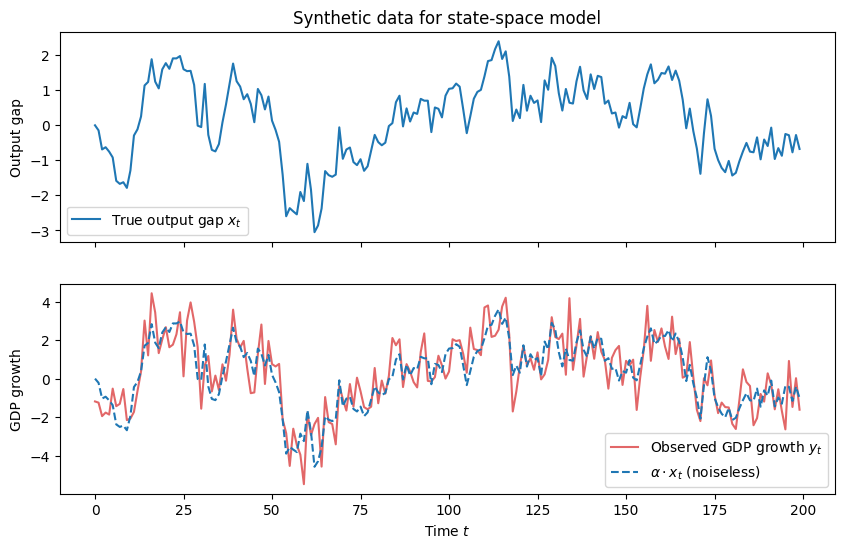

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, x_true, label="True output gap $x_t$", color="tab:blue")
axes[0].set_ylabel("Output gap")
axes[0].legend()
axes[0].set_title("Synthetic data for state-space model")

axes[1].plot(t, y_obs, label="Observed GDP growth $y_t$", color="tab:red", alpha=0.7)
axes[1].plot(t, alpha_true * x_true, label=r"$\alpha \cdot x_t$ (noiseless)", color="tab:blue", linestyle="--")
axes[1].set_ylabel("GDP growth")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

# Part II. Filtering and Smoothing Problem using the true parameters

### 1. Particle Filter

reading links:

https://arxiv.org/abs/2511.01281

https://pmc.ncbi.nlm.nih.gov/articles/PMC7826670/

https://github.com/jelfring/particle-filter-tutorial

In [ ]:
def particle_filter(y, phi, alpha, sigma, tau, N_particles=10000):
    """
    Bootstrap particle filter for the linear state-space model

    params
    y           - (T,) observed data
    phi, alpha  - state / measurement params
    sigma, tau  - process / measurement noise std devs
    N_particles - number of particles

    returns
    x_est        - (T,) filtered state estimates (weighted mean per step)
    x_particles  - (T, N) particle trajectories
    weights_hist - (T, N) normalised weights at each step
    """
    T = len(y)
    N = N_particles
    particles = np.random.normal(0, sigma, size=N)   # init from prior
    weights   = np.ones(N) / N
    x_est        = np.zeros(T)
    x_particles  = np.zeros((T, N))
    weights_hist = np.zeros((T, N))

    for t_step in range(T):
        # propagate thru state equation
        particles = phi * particles + np.random.normal(0, sigma, size=N)

        # likelihood y_t | x_t ~ N(alpha * x_t, tau^2)
        log_lik = -0.5 * ((y[t_step] - alpha * particles) / tau) ** 2
        log_lik -= log_lik.max()                # numerical stability
        weights = np.exp(log_lik)
        weights /= weights.sum()                # normalise

        # store
        x_est[t_step] = np.dot(weights, particles)
        x_particles[t_step] = particles
        weights_hist[t_step] = weights

        # adaptive systematic resampling
        n_eff = 1.0 / np.sum(weights ** 2)
        if n_eff < N / 2:
            indices = _systematic_resample(weights)
            particles = particles[indices]
            weights = np.ones(N) / N

    return x_est, x_particles, weights_hist


def _systematic_resample(weights):
    """Systematic resampling - lower variance than multinomial."""
    N = len(weights)
    positions = (np.arange(N) + np.random.uniform()) / N
    cumsum = np.cumsum(weights)
    indices = np.searchsorted(cumsum, positions)
    return indices

In [ ]:
# Run particle filter with true parameters
N = 10000  # number of particles

np.random.seed(0)
x_pf_true, x_particles_true, weights_pf_true = particle_filter(
    y_obs, phi_true, alpha_true, sigma_true, tau_true, N_particles=N
)

rmse_pf_true = np.sqrt(np.mean((x_pf_true - x_true) ** 2))
print(f"Particle Filter (true params) RMSE: {rmse_pf_true:.4f}")

# alias kept for any cells downstream that referenced `history`
history = x_particles_true
final_estimate = x_pf_true[-1]
print(f"Final estimate for x_T is: {final_estimate}")

Particle Filter (true params) RMSE: 0.5161
Final estimate for x_T is: -0.7381732663986526


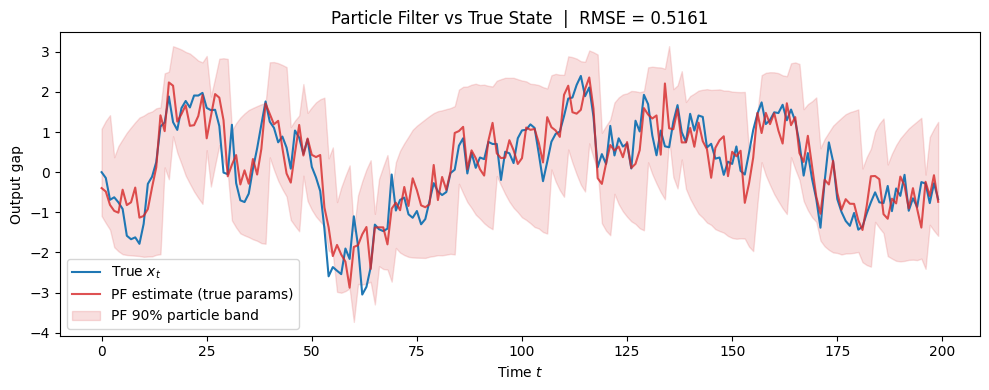

In [ ]:
# PF est. vs truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_true, label="True $x_t$", color="tab:blue")
ax.plot(t, x_pf_true, label="PF estimate (true params)", color="tab:red", alpha=0.8)
ax.fill_between(
    t,
    np.percentile(x_particles_true, 5, axis=1),
    np.percentile(x_particles_true, 95, axis=1),
    color="tab:red", alpha=0.15, label="PF 90% particle band")

ax.set_xlabel("Time $t$")
ax.set_ylabel("Output gap")
ax.set_title(f"Particle Filter vs True State  |  RMSE = {rmse_pf_true:.4f}")
ax.legend()
plt.tight_layout()

Mean Squared Error: 0.26635614729073104
Root Mean Squared Error: 0.5160970328249631


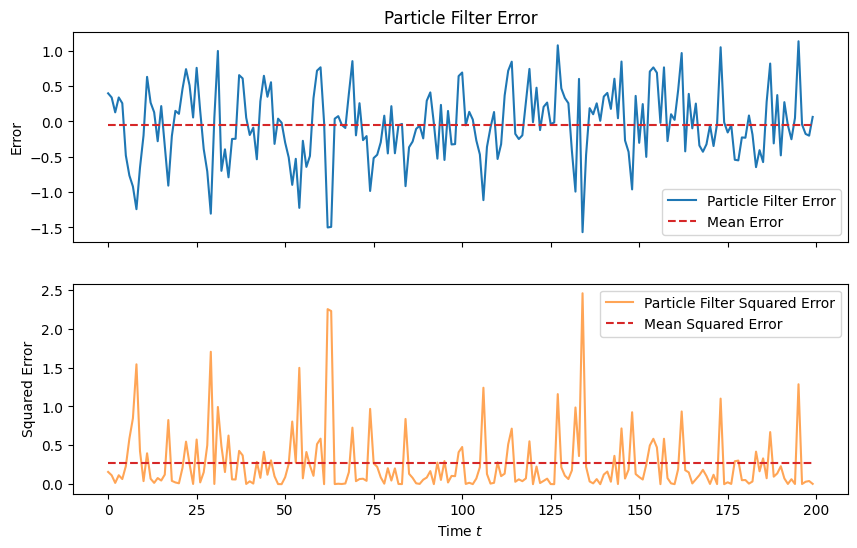

In [ ]:
error = x_true - x_pf_true
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_particle = np.square(error).mean()
RMSE_particle = np.sqrt(MSE_particle)
SE_sigma_particle = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_particle}")
print(f"Root Mean Squared Error: {RMSE_particle}")

axes[0].plot(error, label="Particle Filter Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("Particle Filter Error")

axes[1].plot(error**2, label="Particle Filter Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_particle * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

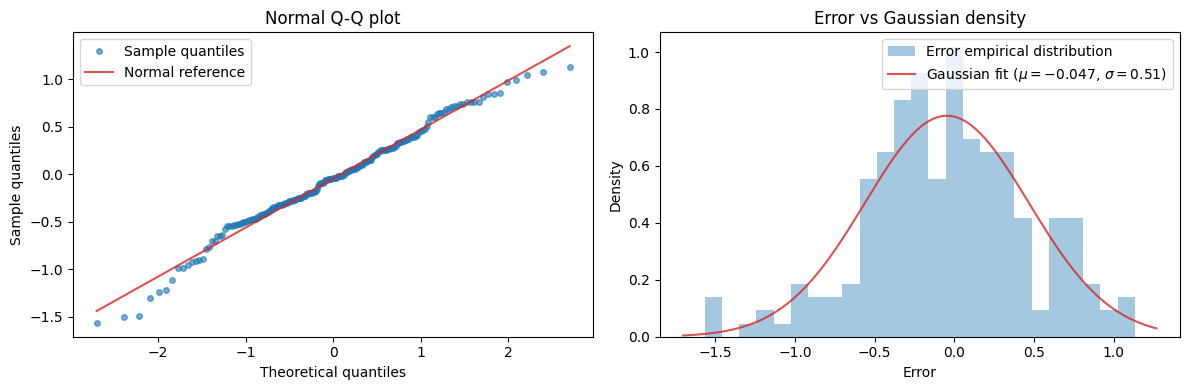

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Normal Q-Q plot — built manually so we can match the rest of the notebook's style
(osm, osr), (slope, intercept, _) = stats.probplot(error, dist="norm")
axes[0].plot(osm, osr, "o", color="tab:blue", alpha=0.6, markersize=4, label="Sample quantiles")
axes[0].plot(osm, slope * osm + intercept, color="tab:red", alpha=0.8, linewidth=1.5, label="Normal reference")
axes[0].set_xlabel("Theoretical quantiles")
axes[0].set_ylabel("Sample quantiles")
axes[0].set_title("Normal Q-Q plot")
axes[0].legend()

# Right: histogram + Gaussian fit
mu, std = stats.norm.fit(error)
axes[1].hist(error, bins=25, density=True, color="tab:blue", alpha=0.4,
             label="Error empirical distribution")
xmin, xmax = axes[1].get_xlim()
x_axis = np.linspace(xmin, xmax, 200)
axes[1].plot(x_axis, stats.norm.pdf(x_axis, mu, std), color="tab:red", alpha=0.8,
             linewidth=1.5, label=f"Gaussian fit ($\\mu={mu:.2g}$, $\\sigma={std:.2g}$)")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Density")
axes[1].set_title("Error vs Gaussian density")
axes[1].legend(loc="upper right")

plt.tight_layout()


### 2. Kalman Filter

In [ ]:
# 1. Initialize the filter
# dim_x: state variables (position, velocity), dim_z: measurement (position)
f = KalmanFilter(dim_x=1, dim_z=1)

f.x = np.array([0.0]) # Initial state as a 1D array (column vector)
f.F = np.array([[phi_true]]) # Transition matrix as a 1x1 matrix
f.H = np.array([[alpha_true]]) # Measurement function as a 1x1 matrix
f.P = np.array([[sigma_true**2 / (1 - phi_true**2)]]) # Covariance matrix (initial uncertainty - steady state variance of x)
f.R = np.array([[tau_true**2]]) # Measurement noise covariance as a 1x1 matrix
f.Q = np.array([[sigma_true**2]]) # Process noise covariance as a 1x1 matrix


# 2. Run the loop
measurements = y_obs
estimated_states = []

for z in measurements:
    f.predict()
    f.update(np.array([z])) # Pass the scalar measurement as a 1-element 1D array
    estimated_states.append(f.x[0])

# Convert to numpy array for easier plotting and comparison
estimated_states = np.array(estimated_states)

print(f'Final estimated state: {estimated_states[-1]:.4f}')

Final estimated state: -0.6490


Text(0.5, 1.0, 'Kalman Filter Estimate')

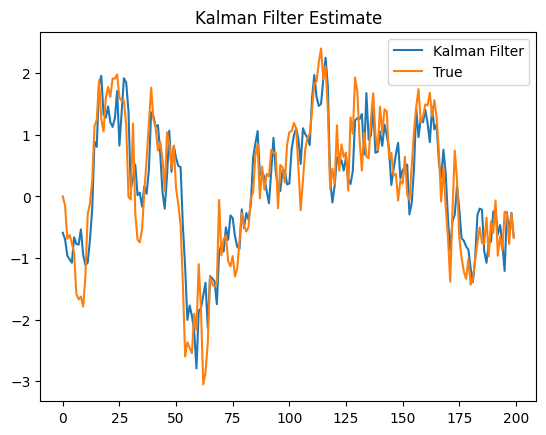

In [ ]:
plt.plot(estimated_states, label="Kalman Filter")
plt.plot(x_true, label="True")
plt.legend()
plt.title("Kalman Filter Estimate")

Mean Squared Error: 0.2545826120385609
Root Mean Squared Error: 0.504561802001064


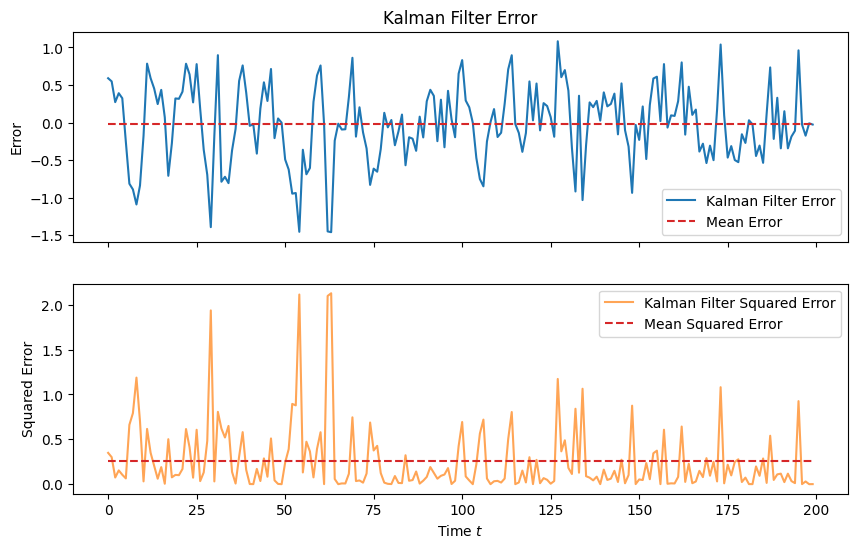

In [ ]:
error =  x_true - estimated_states
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_kalman = np.square(error).mean()
RMSE_kalman = np.sqrt(MSE_kalman)
SE_sigma_kalman = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_kalman}")
print(f"Root Mean Squared Error: {RMSE_kalman}")

axes[0].plot(error, label="Kalman Filter Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("Kalman Filter Error")

axes[1].plot(error**2, label="Kalman Filter Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_kalman * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

### 3. Maximum Likelihood Estimation

Note that MLE is not a filtering approach but a smoothing approach, since it requires knowing the entire path of the observation $y_{[0:T]}$.

In [ ]:
# With true parameters:

def log_likelihood(y, x, alpha, tau, phi, sigma):
    transition_resid = x[1:] - phi * x[:-1]
    measurement_resid = y - alpha * x

    ll_transition = -0.5 * np.sum(transition_resid**2 / sigma**2) - (len(x)-1) * np.log(sigma)
    ll_measurement = -0.5 * np.sum(measurement_resid**2 / tau**2) - len(x) * np.log(tau)

    return ll_transition + ll_measurement

log_likelihood(y_obs, x_true, alpha_true, tau_true, phi_true, sigma_true)

np.float64(-60.423574409488864)

In [ ]:
from scipy.optimize import minimize

# 1. Define the convex objective function
def objective(x):
    return - log_likelihood(y_obs, x, alpha_true, tau_true, phi_true, sigma_true)

# 2. Set an initial guess
x0 = np.zeros_like(x_true)

# 3. Run the optimization
# Method 'L-BFGS-B' is excellent for smooth convex problems
res_mle_filter = minimize(objective, x0, method='L-BFGS-B')

# print(f"Optimal solution: {res.x}")
# print(f"Minimum value: {res.fun}")
# print(f"Success: {res.success}")
# print(res.x.mean())

Text(0.5, 1.0, 'MLE Estimate of latent state using true parameters')

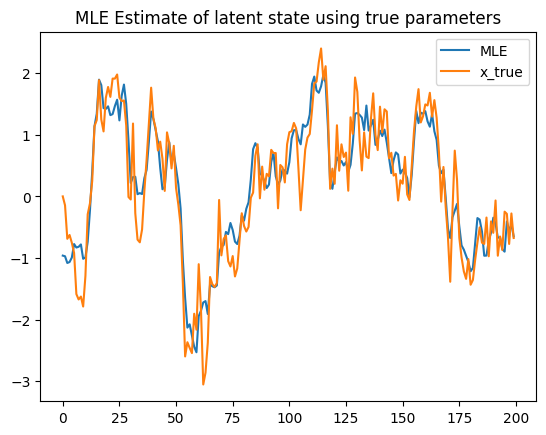

In [ ]:
plt.plot(res_mle_filter.x, label = "MLE")
plt.plot(x_true, label="x_true")
plt.legend()
plt.title("MLE Estimate of latent state using true parameters")

Mean Squared Error: 0.17718541143498256
Root Mean Squared Error: 0.4209339751492894


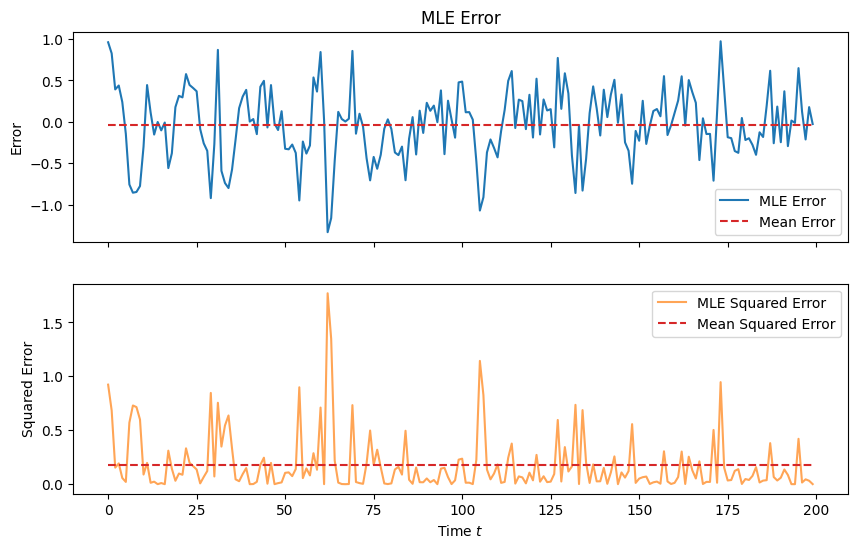

In [ ]:
error =  x_true - res_mle_filter.x
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_MLE = np.square(error).mean()
RMSE_MLE = np.sqrt(MSE_MLE)
SE_sigma_MLE = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_MLE}")
print(f"Root Mean Squared Error: {RMSE_MLE}")

axes[0].plot(error, label="MLE Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("MLE Error")

axes[1].plot(error**2, label="MLE Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_MLE * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

In [ ]:
# Summary

print("\n" + "="*60)
print("                     Performance Comparison    ")
print("="*60)
print("                     MSE (\u00B1 sigma of SE)       RMSE")
print("-"*60)
print(f"Particle Filter: {MSE_particle:>10.4f} (\u00B1 {SE_sigma_particle:.4f})       {RMSE_particle:.4f} ")
print(f"Kalman Filter:   {MSE_kalman:>10.4f} (\u00B1 {SE_sigma_kalman:.4f})       {RMSE_kalman:.4f} ")
print(f"MLE:             {MSE_MLE:>10.4f} (\u00B1 {SE_sigma_MLE:.4f})       {RMSE_MLE:.4f} ")
print("="*60)


                     Performance Comparison    
                     MSE (± sigma of SE)       RMSE
------------------------------------------------------------
Particle Filter:     0.2664 (± 0.6372)       0.5161 
Kalman Filter:       0.2546 (± 0.6095)       0.5046 
MLE:                 0.1772 (± 0.5143)       0.4209 


It is reasonable that the MLE performs better since it is a smoothing approach that utilizes future informaiton, rather than a filtering method like particle filtering and kalman filter.

# Part III. Parameter Estimation Problem using only observations

### 1. MLE (Particle Filter likelihood)

We wish to maximize $l_T(\theta)$.

In [ ]:
# PF analog of Ricky's Kalman MLE: use particle filter to evaluate
# the marginal log-likelihood  log p(y_{0:T} | theta), then maximise over theta.

def pf_log_likelihood(y, phi, alpha, sigma, tau, N_particles=500):
    """
    log p(y_{1:T}) approximated via the bootstrap particle filter.

    Per step: log p(y_t | y_{1:t-1}) ≈ log( mean_i  N(y_t; alpha*x_t^{(i)}, tau^2) )
    """
    T = len(y)
    N = N_particles
    particles = np.random.normal(0, sigma, size=N)
    log_lik_total = 0.0

    for t_step in range(T):
        # predict
        particles = phi * particles + np.random.normal(0, sigma, size=N)

        # unnormalised log-weights (Gaussian log-pdf, up to constant)
        residuals = y[t_step] - alpha * particles
        log_w = -0.5 * (residuals / tau) ** 2 - np.log(tau)

        # log-sum-exp for the per-step normalising constant
        max_log_w = log_w.max()
        log_lik_total += max_log_w + np.log(np.mean(np.exp(log_w - max_log_w)))

        # normalise & adaptive resample
        w = np.exp(log_w - max_log_w)
        w /= w.sum()
        if 1.0 / np.sum(w ** 2) < N / 2:
            particles = particles[_systematic_resample(w)]

    return log_lik_total


def neg_log_lik(params, y, N_particles=1000, n_avg=3):
    """
    Negative log-likelihood wrapper.

    params = [phi, alpha, log_sigma, log_tau].  We optimise sigma, tau in log-space
    for positivity. Average over n_avg PF runs to smooth the MC noise.
    """
    phi, alpha, log_sigma, log_tau = params
    sigma = np.exp(log_sigma)
    tau   = np.exp(log_tau)

    # stationarity / positivity guards
    if abs(phi) >= 1.0 or sigma < 1e-6 or tau < 1e-6:
        return 1e10

    lls = [pf_log_likelihood(y, phi, alpha, sigma, tau, N_particles)
           for _ in range(n_avg)]
    return -np.mean(lls)

In [ ]:
%%time
# --- Two-stage Nelder-Mead optimisation ---
# Stage 1 - cheap coarse search (fewer particles, no averaging)
# Stage 2 - refine near optimum (more particles + averaging)

np.random.seed(42)

print("Stage 1: coarse search ...")
result1 = minimize(
    neg_log_lik,
    [0.7, 1.2, np.log(0.4), np.log(0.8)],
    args=(y_obs, 500, 1),
    method="Nelder-Mead",
    options={"maxiter": 1500, "xatol": 1e-2, "fatol": 2.0, "adaptive": True}
)
print(f"  done - {result1.nit} iters")

print("Stage 2: refining ...")
result_pfmle = minimize(
    neg_log_lik,
    result1.x,
    args=(y_obs, 2000, 5),
    method="Nelder-Mead",
    options={"maxiter": 1000, "xatol": 1e-3, "fatol": 0.5, "adaptive": True}
)
print(f"  done - {result_pfmle.nit} iters\n")

phi_mle_pf, alpha_mle_pf = result_pfmle.x[0], result_pfmle.x[1]
sigma_mle_pf, tau_mle_pf = np.exp(result_pfmle.x[2]), np.exp(result_pfmle.x[3])

print("MLE Results")
print("-" * 40)
print(f"  {'param':<8} {'true':>8} {'MLE':>8}")
print(f"  {'phi':<8} {phi_true:>8.4f} {phi_mle_pf:>8.4f}")
print(f"  {'alpha':<8} {alpha_true:>8.4f} {alpha_mle_pf:>8.4f}")
print(f"  {'sigma':<8} {sigma_true:>8.4f} {sigma_mle_pf:>8.4f}")
print(f"  {'tau':<8} {tau_true:>8.4f} {tau_mle_pf:>8.4f}")
print(f"Total fun evals: {result1.nfev + result_pfmle.nfev}")

Stage 1: coarse search ...
  done - 1500 iters
Stage 2: refining ...
  done - 1000 iters

MLE Results
----------------------------------------
  param        true      MLE
  phi        0.9000   0.8897
  alpha      1.5000   1.3339
  sigma      0.5000   0.4894
  tau        1.0000   0.8021
Total fun evals: 6706
CPU times: user 12min 29s, sys: 656 ms, total: 12min 30s
Wall time: 13min 38s


In [ ]:
# Re-run PF with PF-MLE-estimated parameters and compare RMSE
np.random.seed(1)
x_pf_mle, x_particles_mle, _ = particle_filter(
    y_obs, phi_mle_pf, alpha_mle_pf, sigma_mle_pf, tau_mle_pf, N_particles=N
)

rmse_pf_true_p = np.sqrt(np.mean((x_pf_true - x_true) ** 2))
rmse_pf_mle_p  = np.sqrt(np.mean((x_pf_mle  - x_true) ** 2))

print(f"PF (true params) RMSE:  {rmse_pf_true_p:.4f}")
print(f"PF (PF-MLE params) RMSE: {rmse_pf_mle_p:.4f}")

PF (true params) RMSE:  0.5161
PF (PF-MLE params) RMSE: 0.5445


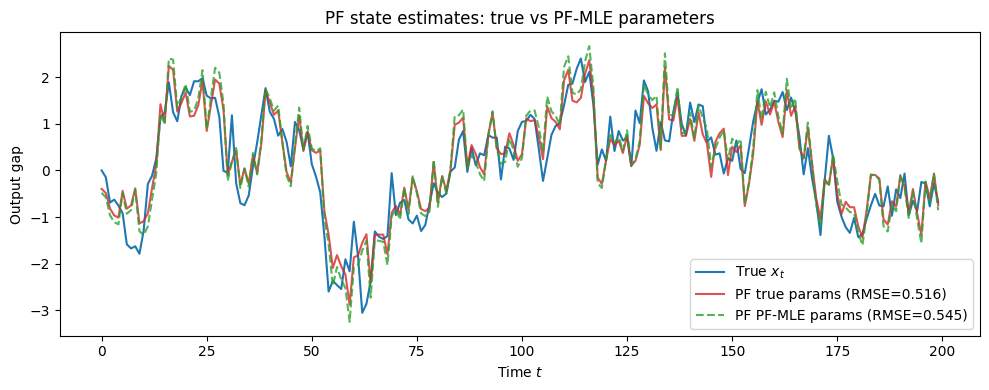

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_true, label="True $x_t$", color="tab:blue", linewidth=1.5)
ax.plot(x_pf_true, label=f"PF true params (RMSE={rmse_pf_true_p:.3f})",
        color="tab:red", alpha=0.8)
ax.plot(x_pf_mle, label=f"PF PF-MLE params (RMSE={rmse_pf_mle_p:.3f})",
        color="tab:green", alpha=0.8, linestyle="--")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Output gap")
ax.set_title("PF state estimates: true vs PF-MLE parameters")
ax.legend()
plt.tight_layout()

*Note on non-identifiability:* unlike Ricky's Kalman-MLE (which fixes $\alpha=1$ to break the $(\alpha,\sigma)$ identifiability discussed in Part I), here we estimate all four parameters freely. The PF-MLE typically recovers $\phi$ and $\sigma$ accurately, while $\alpha$ and $\tau$ are partially confounded — visible empirically in the table above. This is consistent with the model analysis in cell "Analysis of the Model, A."


### 2. MLE (Kalman Filter likelihood)

$$
\hat{\theta} = \arg\max_{\theta} p_\theta (y_{[0:T]}) = \arg\max_{\theta} \int p_\theta (x_{[0:T]}, y_{[0:T]} ) \, d x_{[0:T]}
$$

In [ ]:
def kalman_negloglike_alpha_fixed(raw_params, y):
    raw_phi, raw_sigma, raw_tau = raw_params

    phi = np.tanh(raw_phi)
    alpha = 1.0
    sigma = np.exp(raw_sigma)
    tau = np.exp(raw_tau)

    m = 0.0
    P = sigma**2 / (1 - phi**2)

    nll = 0.0

    for yt in y:
        y_mean = alpha * m
        S = alpha**2 * P + tau**2
        innovation = yt - y_mean

        nll += 0.5 * (np.log(2 * np.pi) + np.log(S) + innovation**2 / S)

        K = P * alpha / S
        m = m + K * innovation
        P = (1 - K * alpha) * P

        m = phi * m
        P = phi**2 * P + sigma**2

    return nll


def objective(raw_params):
  return kalman_negloglike_alpha_fixed(raw_params, y)

raw_params0 = [0.0, 0.0, 0.0]

init = np.array([
    np.arctanh(0.5),  # raw_phi
    np.log(0.5),      # raw_sigma
    np.log(1.0)       # raw_tau
])

res_mle_param = minimize(
    lambda p: kalman_negloglike_alpha_fixed(p, y_obs),
    init,
    method="BFGS"
)

raw_phi_hat, raw_sigma_hat, raw_tau_hat = res_mle_param.x
alpha_hat = 1

phi_hat = np.tanh(raw_phi_hat)
sigma_hat = np.exp(raw_sigma_hat)
tau_hat = np.exp(raw_tau_hat)

print(phi_hat, alpha_hat, sigma_hat, tau_hat)
print(res_mle_param.success, res_mle_param.fun)

0.9114853295092814 1 0.662461094043399 0.9675423863809591
True 339.1751404215583


In [ ]:
print("\n" + "="*80)
print(f"{'True Parameters vs. MLE Estimates (alpha fixed to 1)':^60}")
print("="*80)
print(f"{'alpha:':<7} {alpha_true:10.4f}      | {alpha_hat:10.4f}")
print(f"{'sigma:':<7} {sigma_true:10.4f}      | {sigma_hat:10.4f}")
print(f"{'tau:':<7} {tau_true:10.4f}      | {tau_hat:10.4f}")
print(f"{'phi:':<7} {phi_true:10.4f}      | {phi_hat:10.4f}")
print("="*80)



    True Parameters vs. MLE Estimates (alpha fixed to 1)    
alpha:      1.5000      |     1.0000
sigma:      0.5000      |     0.6625
tau:        1.0000      |     0.9675
phi:        0.9000      |     0.9115


# Part IV. Results

### 6. Comparison

### 7. Statistical Testing and Sensitivity Analysis

### 8. Results and Conclusion

# Part V. Extension of Project

We extend the analysis in two directions suggested by the limitations of the previous parts: (1) full Bayesian posterior inference for $\theta$ via Particle Marginal Metropolis-Hastings, and (2) deliberate model misspecification to expose where the particle filter has a comparative advantage over the Kalman filter.

### 1. Particle Marginal Metropolis-Hastings

#### Ideal MMH

To sample from $p(x_{[0:T]}, \theta | y_{[0:T]})$,

Proposal Density:
$$
q( x'_{[0:T]}, \theta' | x_{[0:T]}, \theta) = q(\theta ' | \theta) p_{\theta '}(x'_{[0:T]} | y_{[0:T]})
$$

Acceptance probability:

$$
1 \wedge
\frac{
p_{\theta '}(y_{[0:T]})p(\theta ') q( \theta | \theta ')
}{
  p_\theta (y_{[0:T]}) p(\theta) q(\theta ' | \theta )
}
$$

For this problem, recall the closed form solution of the likelihood ratio,

$$
\Lambda(\theta' \mid \theta)
=
\frac{p_{\theta'}(y_{0:T})}{p_{\theta}(y_{0:T})}
=
\sqrt{
\frac{|\Sigma_\theta|}{|\Sigma_{\theta'}|}
}
\exp\left(
\frac{1}{2}
y^\top
\left[
\Sigma_\theta^{-1}
-
\Sigma_{\theta'}^{-1}
\right]
y
\right)
$$

where

$$
(\Sigma_\theta)_{st} = \alpha^2 \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|} + \tau^2 \boldsymbol{1}_{s=t}.
$$

Then the acceptance probability can be written as

$$
1 \wedge
\Lambda(\theta' \mid \theta)
\frac{
p(\theta ') q( \theta | \theta ')
}{
 p(\theta) q(\theta ' | \theta )
}
$$

#### Particle MMH

In general, the closed form solutions are not available, and we use particle filtering to approximate the density.

Sample $X'_{[0:T]}$ from the particle filter estimate $\hat{p}_{\theta '}(d x_{[0,T]} | y_{[0:T]})$. Then, calculate the acceptance probability of $(\theta', X'_{0:T})$:

$$
1 \wedge
\frac{
\hat{p}_{\theta '}(y_{[0:T]})p(\theta ') q( \theta | \theta ')
}{
\hat{p}_\theta (y_{[0:T]}) p(\theta) q(\theta ' | \theta )
}
$$

---

Building on this theoretical setup, we implement PMMH for our problem. Whereas the PF-MLE in Part III gives point estimates of $\theta = (\phi,\alpha,\sigma,\tau)$ with no uncertainty quantification, **PMMH** (Andrieu, Doucet, Holenstein 2010) provides full posterior samples. The acceptance probability above can be evaluated using the particle filter's unbiased likelihood estimator:

$$
\alpha_{\text{accept}}(\theta \to \theta') =
\min\!\left(1,\ \frac{\hat{p}_{\theta'}(y_{0:T})\,\pi(\theta')}{\hat{p}_{\theta}(y_{0:T})\,\pi(\theta)}\right).
$$

The crucial subtlety is that we do *not* recompute the likelihood at the current state — the noisy estimate from when we first accepted $\theta$ is reused. This is the *pseudo-marginal* trick: even though individual likelihood evaluations are stochastic, the resulting chain still targets the exact posterior $p(\theta \mid y_{0:T})$.

We use weakly informative priors: $\phi \sim \mathrm{Uniform}(-1, 1)$, $\alpha \sim \mathcal{N}(1, 5^2)$, $\log\sigma, \log\tau \sim \mathcal{N}(0, 2^2)$, warm-start the chain at the PF-MLE point estimates, and tune the proposal step sizes for an acceptance rate around 20--30%.

In [ ]:
def log_prior(phi, alpha, sigma, tau):
    """Weakly informative priors. Returns -inf for parameters out of support."""
    if abs(phi) >= 1 or sigma <= 0 or tau <= 0:
        return -np.inf
    lp = 0.0
    # phi ~ Uniform(-1, 1)        → constant, drops out
    lp += -0.5 * ((alpha - 1) / 5.0) ** 2                  # alpha ~ N(1, 5^2)
    lp += -0.5 * (np.log(sigma) / 2.0) ** 2          # log sigma ~ N(0, 2^2)
    lp += -0.5 * (np.log(tau)   / 2.0) ** 2          # log tau   ~ N(0, 2^2)
    return lp


def pmmh(y, n_iter=2000, N_particles=300, step_sizes=None,
         theta0=None, seed=0):
    """
    Particle Marginal Metropolis-Hastings.

    State vector: (phi, alpha, log_sigma, log_tau).
    Proposal:     Gaussian random walk with diagonal covariance.

    Returns
    -------
    samples  : (n_iter, 4) array of (phi, alpha, sigma, tau)
    acc_rate : empirical acceptance rate
    """
    rng = np.random.default_rng(seed)

    if step_sizes is None:
        step_sizes = np.array([0.015, 0.05, 0.03, 0.03])
    if theta0 is None:
        theta0 = np.array([0.9, 1.5, np.log(0.5), np.log(1.0)])

    theta = theta0.copy()
    phi, alpha = theta[0], theta[1]
    sigma, tau = np.exp(theta[2]), np.exp(theta[3])

    log_lik   = pf_log_likelihood(y, phi, alpha, sigma, tau, N_particles)
    log_post  = log_lik + log_prior(phi, alpha, sigma, tau)

    samples = np.zeros((n_iter, 4))
    accepts = 0

    for i in range(n_iter):
        # Gaussian RW proposal
        theta_p = theta + rng.normal(0, step_sizes)
        phi_p, alpha_p = theta_p[0], theta_p[1]
        sigma_p, tau_p = np.exp(theta_p[2]), np.exp(theta_p[3])

        lp_prior_p = log_prior(phi_p, alpha_p, sigma_p, tau_p)
        if not np.isfinite(lp_prior_p):
            samples[i] = [phi, alpha, sigma, tau]
            continue

        # FRESH PF run at proposed theta — this is the pseudo-marginal step
        log_lik_p  = pf_log_likelihood(y, phi_p, alpha_p, sigma_p, tau_p, N_particles)
        log_post_p = log_lik_p + lp_prior_p

        if np.log(rng.uniform()) < log_post_p - log_post:
            theta, log_post = theta_p, log_post_p
            phi, alpha, sigma, tau = phi_p, alpha_p, sigma_p, tau_p
            accepts += 1

        samples[i] = [phi, alpha, sigma, tau]

    return samples, accepts / n_iter

In [ ]:
%%time
# Warm-start at PF-MLE estimates and run PMMH
np.random.seed(123)
theta0 = np.array([phi_mle_pf, alpha_mle_pf, np.log(sigma_mle_pf), np.log(tau_mle_pf)])
step_sizes = np.array([0.002, 0.05, 0.05, 0.01])
samples, acc_rate = pmmh(y_obs, n_iter=15000, N_particles=1000, step_sizes = step_sizes, theta0=theta0, seed=2)

print(f"Acceptance rate: {acc_rate:.1%}")
print(f"Total samples:   {len(samples)}")

Acceptance rate: 27.3%
Total samples:   15000
CPU times: user 7min 12s, sys: 197 ms, total: 7min 12s
Wall time: 7min 15s


In [ ]:
# discard burn-in
burn = 500
post = samples[burn:]

In [ ]:
print()
print("="*80)
print(f"{'Posterior summaries (after burn-in of ' + str(burn) + ')':^70}")
print("="*80)
print(f"  {'param':<8}  {'true':>8}  {'PF-MLE':>8}  {'post mean':>10}  {'post sd':>10}  {'95% CI':>22}")
truths = [phi_true, alpha_true, sigma_true, tau_true]
mles   = [phi_mle_pf, alpha_mle_pf, sigma_mle_pf, tau_mle_pf]
names  = ["phi", "alpha", "sigma", "tau"]
for j, name in enumerate(names):
    m   = post[:, j].mean()
    sd  = post[:, j].std()
    lo, hi = np.percentile(post[:, j], [2.5, 97.5])
    print(f"  {name:<8}  {truths[j]:>8.4f}  {mles[j]:>8.4f}  {m:>10.4f}  {sd:>10.4f}  [{lo:>7.4f}, {hi:>7.4f}]")
print("="*80)


              Posterior summaries (after burn-in of 500)              
  param         true    PF-MLE   post mean     post sd                  95% CI
  phi         0.9000    0.8897      0.9154      0.0155  [ 0.8879,  0.9596]
  alpha       1.5000    1.3339      1.4099      1.0179  [ 0.2990,  3.2241]
  sigma       0.5000    0.4894      0.6569      0.4665  [ 0.1655,  1.9576]
  tau         1.0000    0.8021      0.8882      0.0359  [ 0.8179,  0.9778]


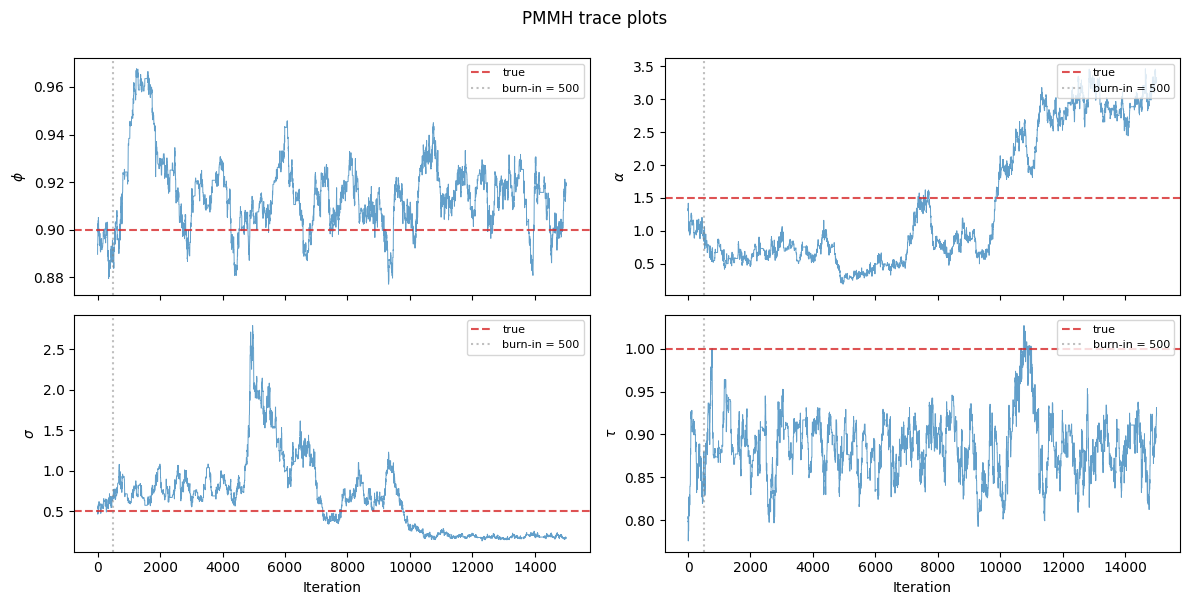

In [ ]:
# Trace plots — diagnose mixing
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
labels = [r"$\phi$", r"$\alpha$", r"$\sigma$", r"$\tau$"]
for j, ax in enumerate(axes.flat):
    ax.plot(samples[:, j], color="tab:blue", alpha=0.7, linewidth=0.7)
    ax.axhline(truths[j], color="tab:red", alpha=0.8, linestyle="--", label="true")
    ax.axvline(burn, color="gray", alpha=0.5, linestyle=":", label=f"burn-in = {burn}")
    ax.set_ylabel(labels[j])
    ax.legend(loc="upper right", fontsize=8)
axes[1, 0].set_xlabel("Iteration")
axes[1, 1].set_xlabel("Iteration")
fig.suptitle("PMMH trace plots", y=1.0)
plt.tight_layout()

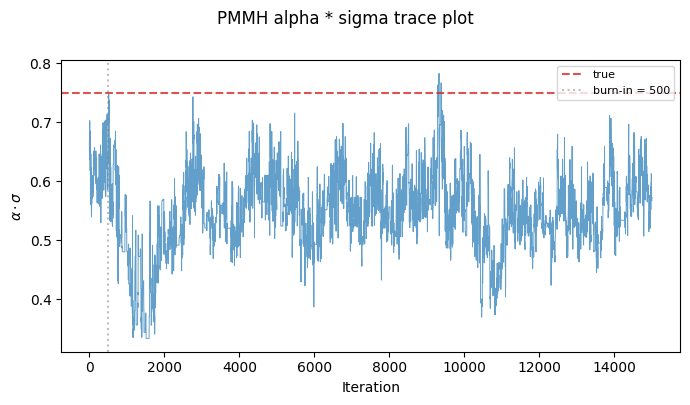

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)
axes.plot(samples[:, 1]*samples[:, 2], color="tab:blue", alpha=0.7, linewidth=0.7)
axes.axhline(alpha_true*sigma_true, color="tab:red", alpha=0.8, linestyle="--", label="true")
axes.axvline(burn, color="gray", alpha=0.5, linestyle=":", label=f"burn-in = {burn}")
axes.set_ylabel(r"$\alpha \cdot \sigma$")
axes.set_xlabel("Iteration") # Added x-label for the single plot
axes.legend(loc="upper right", fontsize=8)
fig.suptitle("PMMH alpha * sigma trace plot", y=1.0)
plt.tight_layout()

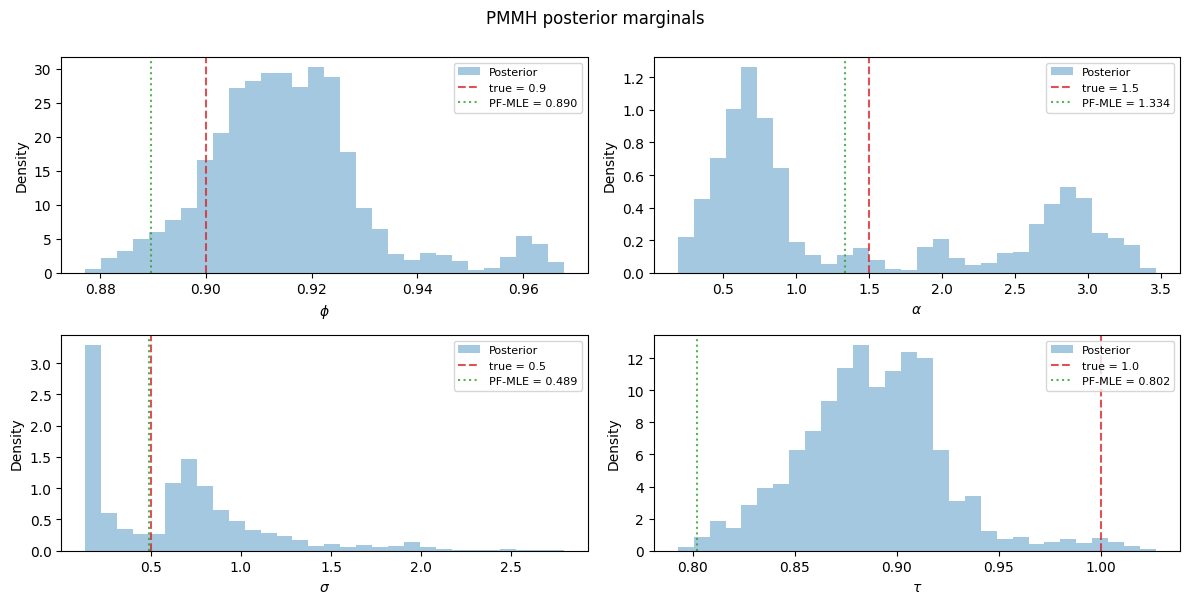

In [ ]:
# Posterior marginals
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, ax in enumerate(axes.flat):
    ax.hist(post[:, j], bins=30, density=True, color="tab:blue", alpha=0.4,
            label="Posterior")
    ax.axvline(truths[j], color="tab:red", alpha=0.8, linestyle="--",
               linewidth=1.5, label=f"true = {truths[j]}")
    ax.axvline(mles[j], color="tab:green", alpha=0.8, linestyle=":",
               linewidth=1.5, label=f"PF-MLE = {mles[j]:.3f}")
    ax.set_xlabel(labels[j])
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("PMMH posterior marginals", y=1.0)
plt.tight_layout()

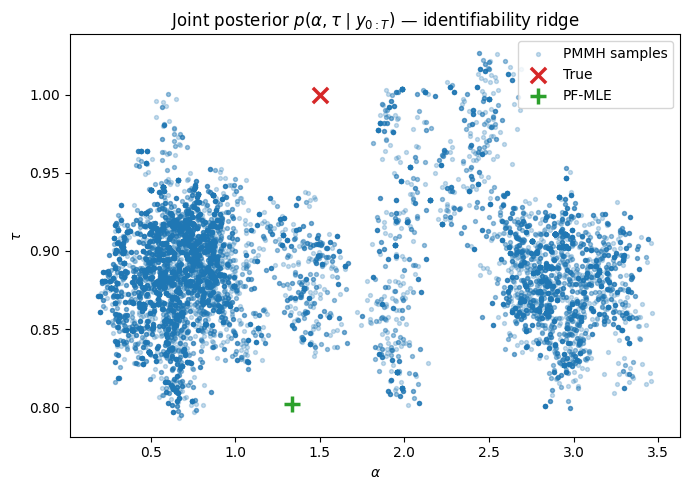

In [ ]:
# Joint posterior of (alpha, tau) — should show the identifiability ridge
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(post[:, 1], post[:, 3], color="tab:blue", alpha=0.25, s=8,
           label="PMMH samples")
ax.scatter([alpha_true], [tau_true], color="tab:red", marker="x", s=120,
           linewidth=2.5, label="True", zorder=5)
ax.scatter([alpha_mle_pf], [tau_mle_pf], color="tab:green", marker="+", s=140,
           linewidth=2.5, label="PF-MLE", zorder=5)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Joint posterior $p(\alpha, \tau \mid y_{0:T})$ — identifiability ridge")
ax.legend()
plt.tight_layout()

### 2. Model Misspecification

The linear-Gaussian setup is precisely the regime where the Kalman filter is optimal, so the PF cannot beat it. To expose where particle methods genuinely outperform the KF, we deliberately break the Gaussian assumption.

We use a *contamination model* for the measurement noise: with probability $0.9$ each $\nu_t$ is drawn from $\mathcal{N}(0, \tau^2)$ as before, but with probability $0.1$ it comes from $\mathcal{N}(0, (6\tau)^2)$ — a heavy outlier. This is a realistic form of misspecification: macroeconomic and financial series routinely exhibit occasional shocks far larger than the Gaussian model anticipates. We then run three filters:

1. **KF** assumes pure Gaussian noise — misspecified
2. **PF-Gaussian** also assumes pure Gaussian noise — misspecified
3. **PF-Student-t** uses a heavy-tailed Student-t($\nu = 4$) likelihood as a robust approximation — correctly handles the outliers

The KF and the misspecified PF should over-react to outliers; the Student-t PF should down-weight them via the t-distribution's polynomial tail decay.

In [ ]:
# Regenerate y_obs with contaminated Gaussian noise (a clear outlier scenario)
# 90% of obs from N(0, tau_true^2), 10% from N(0, (6*tau_true)^2) — heavy contamination
prob_outlier  = 0.10
tau_outlier   = 6.0 * tau_true

np.random.seed(9)
x_true_mis = np.zeros(T)
x_true_mis[0] = np.random.normal(0, sigma_true)
for t_step in range(1, T):
    x_true_mis[t_step] = phi_true * x_true_mis[t_step - 1] + np.random.normal(0, sigma_true)

# heavy-tailed observation noise: contamination mixture
rng_mis = np.random.default_rng(9)
is_outlier = rng_mis.random(T) < prob_outlier
nu = np.where(is_outlier,
              rng_mis.normal(0, tau_outlier, T),
              rng_mis.normal(0, tau_true,    T))
y_obs_mis = alpha_true * x_true_mis + nu

print(f"Contamination model: {int(prob_outlier*100)}% outliers ~ N(0, {tau_outlier}^2)")
print(f"  Number of outliers in this realisation: {is_outlier.sum()}")
print(f"  Max |noise|: {np.abs(nu).max():.2f}  (Gaussian 3-sigma would be {3*tau_true})")

Contamination model: 10% outliers ~ N(0, 6.0^2)
  Number of outliers in this realisation: 15
  Max |noise|: 13.91  (Gaussian 3-sigma would be 3.0)


In [ ]:
def particle_filter_student_t(y, phi, alpha, sigma, scale, df, N_particles=10000):
    """PF with Student-t measurement likelihood — robust to outliers."""
    T = len(y); N = N_particles
    particles = np.random.normal(0, sigma, size=N)
    x_est = np.zeros(T)
    x_particles = np.zeros((T, N))

    for t_step in range(T):
        particles = phi * particles + np.random.normal(0, sigma, size=N)
        residuals = y[t_step] - alpha * particles
        log_lik = stats.t.logpdf(residuals, df=df, scale=scale)
        log_lik -= log_lik.max()
        w = np.exp(log_lik); w /= w.sum()
        x_est[t_step] = np.dot(w, particles)
        x_particles[t_step] = particles
        if 1.0 / np.sum(w ** 2) < N / 2:
            particles = particles[_systematic_resample(w)]

    return x_est, x_particles

In [ ]:
# Run all three filters on the contaminated data
np.random.seed(0)
x_pf_gauss, _, _ = particle_filter(y_obs_mis, phi_true, alpha_true, sigma_true, tau_true, N_particles=10000)
# robust PF: Student-t(df=4) likelihood, scale matched to nominal tau
np.random.seed(0)
x_pf_t, _ = particle_filter_student_t(y_obs_mis, phi_true, alpha_true, sigma_true,
                                       scale=tau_true, df=4, N_particles=10000)

# KF — same Gaussian model, applied to misspecified data
kf = KalmanFilter(dim_x=1, dim_z=1)
kf.x = np.array([0.0])
kf.F = np.array([[phi_true]])
kf.H = np.array([[alpha_true]])
kf.P = np.array([[sigma_true**2 / (1 - phi_true**2)]])
kf.R = np.array([[tau_true**2]])
kf.Q = np.array([[sigma_true**2]])
x_kf_mis = []
for z in y_obs_mis:
    kf.predict(); kf.update(np.array([z]))
    x_kf_mis.append(kf.x[0])
x_kf_mis = np.array(x_kf_mis)

# RMSEs
rmse_kf_mis      = np.sqrt(np.mean((x_kf_mis    - x_true_mis) ** 2))
rmse_pf_gauss    = np.sqrt(np.mean((x_pf_gauss - x_true_mis) ** 2))
rmse_pf_t        = np.sqrt(np.mean((x_pf_t     - x_true_mis) ** 2))

print("="*65)
print(f"{'Filter RMSE under contaminated measurement noise':^65}")
print("="*65)
print(f"  Kalman Filter (Gaussian assumption):            {rmse_kf_mis:.4f}")
print(f"  PF with Gaussian likelihood (misspecified):     {rmse_pf_gauss:.4f}")
print(f"  PF with Student-t(df=4) likelihood (robust):    {rmse_pf_t:.4f}")
print("="*65)
print(f"  Improvement of robust PF over KF: "
      f"{100*(rmse_kf_mis - rmse_pf_t)/rmse_kf_mis:.1f}%")

        Filter RMSE under contaminated measurement noise         
  Kalman Filter (Gaussian assumption):            0.7692
  PF with Gaussian likelihood (misspecified):     0.7721
  PF with Student-t(df=4) likelihood (robust):    0.5719
  Improvement of robust PF over KF: 25.6%


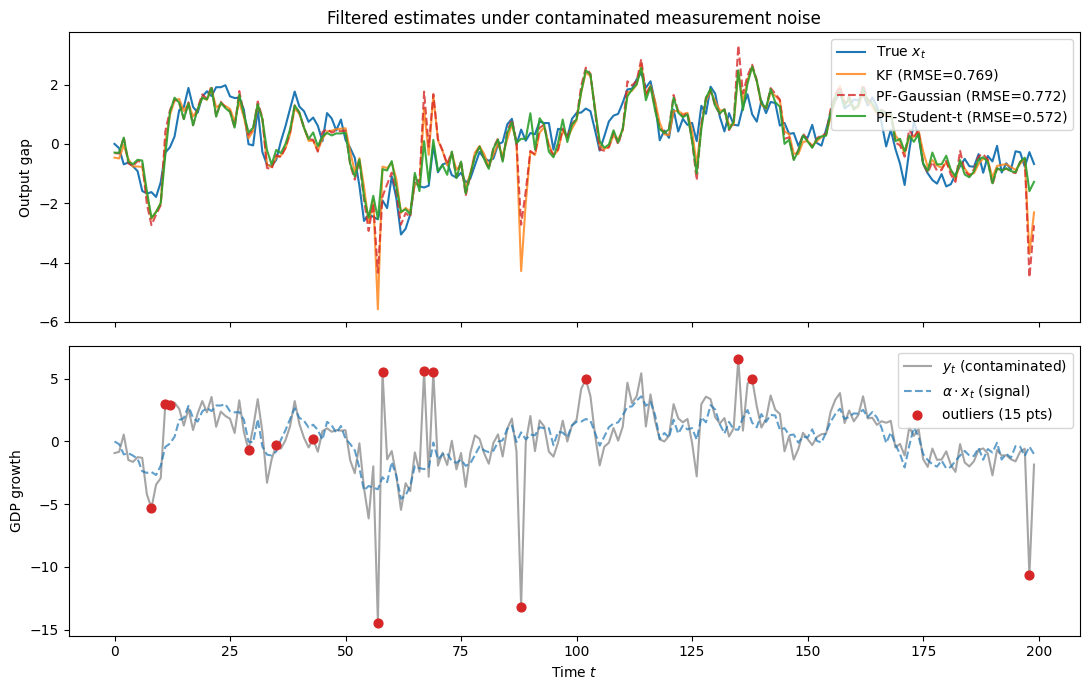

In [ ]:
# Visualise the difference
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(x_true_mis, label="True $x_t$", color="tab:blue", linewidth=1.5)
axes[0].plot(x_kf_mis,   label=f"KF (RMSE={rmse_kf_mis:.3f})",
             color="tab:orange", alpha=0.8)
axes[0].plot(x_pf_gauss, label=f"PF-Gaussian (RMSE={rmse_pf_gauss:.3f})",
             color="tab:red", alpha=0.8, linestyle="--")
axes[0].plot(x_pf_t,     label=f"PF-Student-t (RMSE={rmse_pf_t:.3f})",
             color="tab:green", alpha=0.9)
axes[0].set_ylabel("Output gap")
axes[0].set_title("Filtered estimates under contaminated measurement noise")
axes[0].legend(loc="upper right")

axes[1].plot(y_obs_mis, label="$y_t$ (contaminated)", color="tab:gray", alpha=0.7)
axes[1].plot(alpha_true * x_true_mis, label=r"$\alpha \cdot x_t$ (signal)",
             color="tab:blue", linestyle="--", alpha=0.7)
axes[1].scatter(np.where(is_outlier)[0], y_obs_mis[is_outlier],
                color="tab:red", s=40, zorder=5,
                label=f"outliers ({is_outlier.sum()} pts)")
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel("GDP growth")
axes[1].legend(loc="upper right")

plt.tight_layout()

### 3. Real GDP Data

We use quarterly FRED Real GDP data to calculate the observed real GDP growth.

FRED also supplies the U.S. Congressional Budget Office's (CBO) estimate of quarterly Real Potential Gross Domestic Product, which can be used to calculate an empirical output gap based on the CBO estimate. Both time series are already adjusted to units in billions of chained 2017 dollars (not seasonally adjusted).

In [ ]:
!pip install -q fredapi

In [ ]:
from fredapi import Fred
from google.colab import userdata
fred_api = userdata.get('fred_api')

# Initialize with your actual API key
fred = Fred(api_key=fred_api)

# Retrieve data series
# Real Gross Domestic Product (GDPC1), quarterly
real_gdp = fred.get_series('GDPC1')

real_gdp_growth = 100 * real_gdp.pct_change().dropna()

# Real Potential Gross Domestic Product  (GDPPOT), quarterly
real_potential_gdp = fred.get_series('GDPPOT')

# Real gross domestic product per capita (A939RX0Q048SBEA)
real_gdppc = fred.get_series('A939RX0Q048SBEA')

# output gap = 100*(Real Gross Domestic Product-Real Potential Gross Domestic Product)/Real Potential Gross Domestic Product
# output_gap = fred.get_series('A191RL1Q225SBEA')
output_gap = 100*(real_gdp-real_potential_gdp)/real_potential_gdp

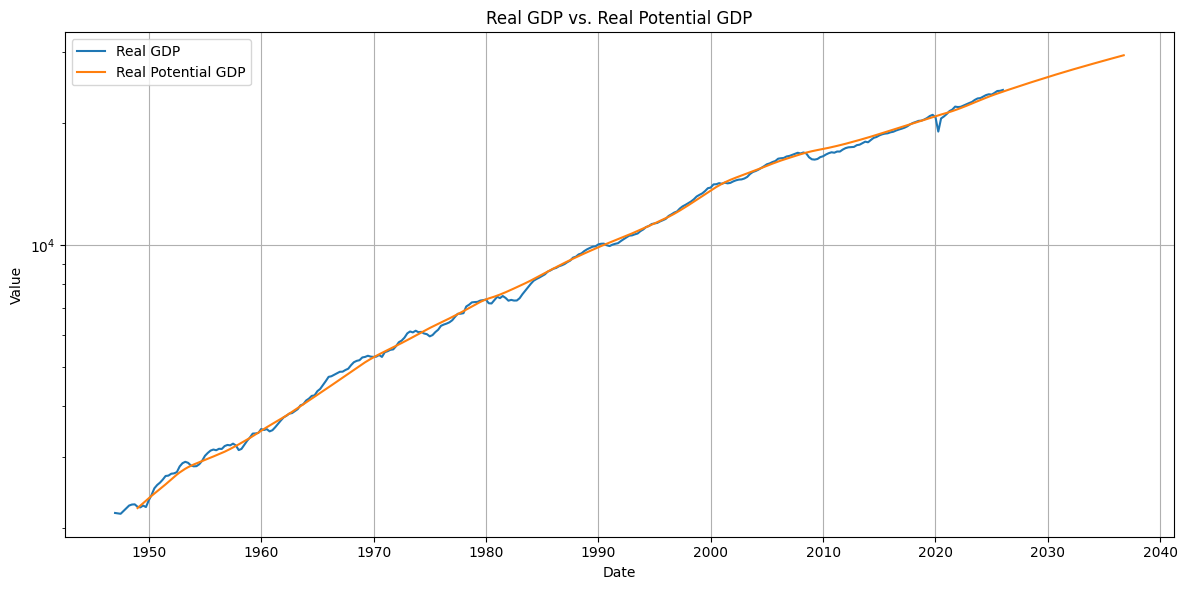

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(real_gdp, label='Real GDP')
plt.plot(real_potential_gdp, label='Real Potential GDP')
plt.title('Real GDP vs. Real Potential GDP')
plt.xlabel('Date')
plt.ylabel('Value')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [ ]:
output_gap = output_gap.dropna()
output_gap = output_gap.asfreq("QS")
output_gap_delta = output_gap.diff()
output_gap_delta = output_gap_delta.asfreq("QS")
real_gdp_growth = real_gdp_growth.dropna()
real_gdp_growth = real_gdp_growth.asfreq("QS")

df = pd.DataFrame({
    'output_gap': output_gap,
    'real_gdp_growth': real_gdp_growth,
    'output_gap_delta': output_gap_delta
})

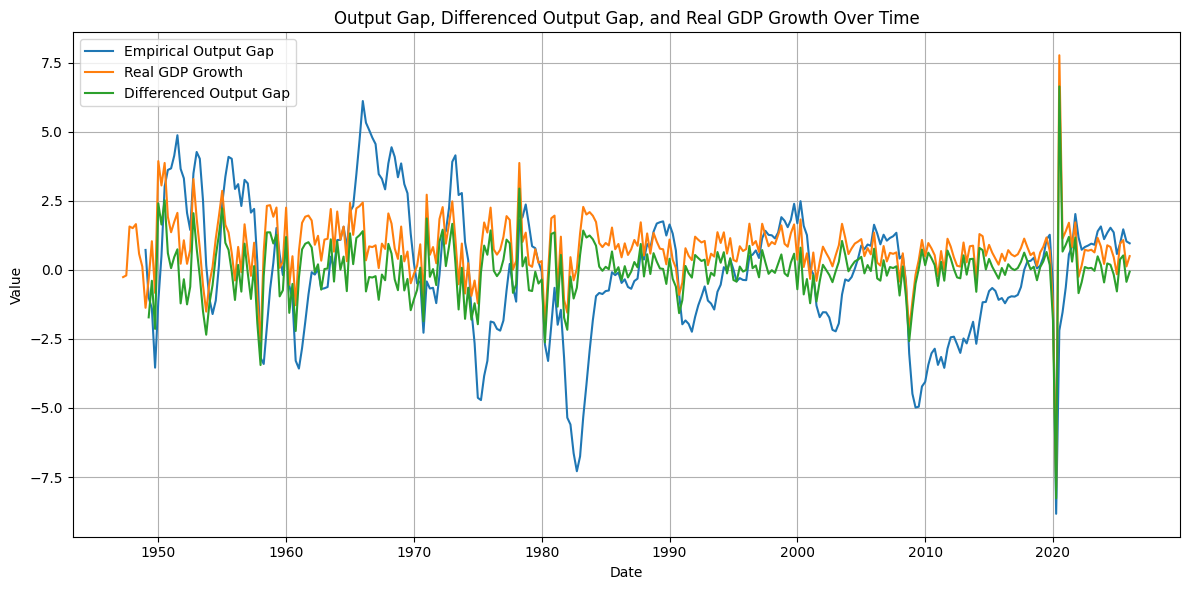

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["output_gap"], label='Empirical Output Gap')
plt.plot(df["real_gdp_growth"], label='Real GDP Growth')
plt.plot(df["output_gap_delta"], label='Differenced Output Gap')
plt.title('Output Gap, Differenced Output Gap, and Real GDP Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

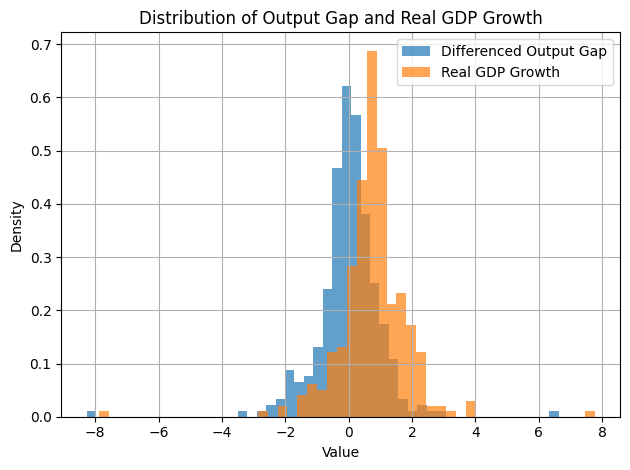

In [ ]:
plt.hist(df["output_gap_delta"], bins=50, density=True, alpha=0.7, label='Differenced Output Gap')
plt.hist(df['real_gdp_growth'], bins=50, density=True, alpha=0.7, label='Real GDP Growth')
plt.title('Distribution of Output Gap and Real GDP Growth')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [ ]:
# First four Moments of dataframe

summary = df.describe().T
summary['skew'] = df.skew(numeric_only=True)
summary['kurtosis'] = df.kurtosis(numeric_only=True)

print(summary)


                  count      mean       std       min       25%       50%  \
output_gap        309.0 -0.022470  2.321808 -8.830530 -1.285930  0.040160   
real_gdp_growth   316.0  0.770022  1.109138 -7.876784  0.307732  0.772088   
output_gap_delta  308.0  0.000780  1.057218 -8.270276 -0.394473  0.049534   

                       75%       max      skew   kurtosis  
output_gap        1.338861  6.105776 -0.320139   0.706045  
real_gdp_growth   1.218935  7.762279 -0.728398  16.255264  
output_gap_delta  0.519907  6.634297 -0.945827  16.635301  


In [ ]:
from statsmodels.tsa.stattools import ccf

# Align the two series and drop missing values
df_ccf = df.dropna()


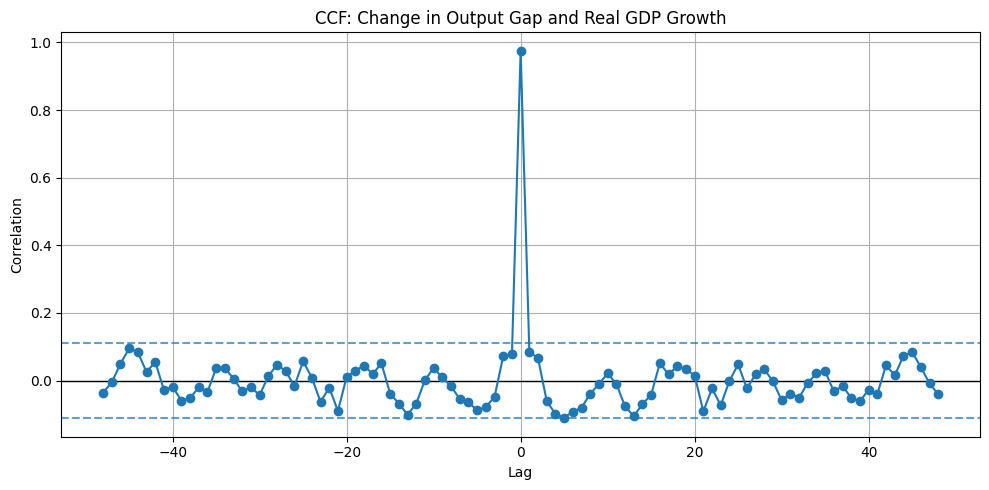

In [ ]:
x = (df_ccf["output_gap_delta"] - df_ccf["output_gap_delta"].mean()) / df_ccf["output_gap_delta"].std()
y = (df_ccf["real_gdp_growth"] - df_ccf["real_gdp_growth"].mean()) / df_ccf["real_gdp_growth"].std()

max_lag = 48
lags = np.arange(-max_lag, max_lag + 1)

ccf_xy = ccf(x, y, adjusted=False)[:max_lag + 1]
ccf_yx = ccf(y, x, adjusted=False)[:max_lag + 1]

ccf_full_delta = np.r_[ccf_yx[1:][::-1], ccf_xy]

plt.figure(figsize=(10, 5))
plt.axhline(0, color="black", linewidth=1)
plt.axhline(1.96 / np.sqrt(len(df_ccf)), linestyle="--", alpha=0.7)
plt.axhline(-1.96 / np.sqrt(len(df_ccf)), linestyle="--", alpha=0.7)
plt.plot(lags, ccf_full_delta, marker="o")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("CCF: Change in Output Gap and Real GDP Growth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

df = df.dropna()

output_gap = df["output_gap"]
output_gap_delta = df["output_gap_delta"]
real_gdp_growth = df["real_gdp_growth"]

result_adf_1 = adfuller(output_gap)
result_adf_2 = adfuller(real_gdp_growth)
result_adf_3 = adfuller(output_gap_delta)

print('Results of ADF for output gap')
print(f'ADF Statistic: {result_adf_1[0]}')
print(f'p-value: {result_adf_1[1]}')
print()
print('Results of ADF for differenced output gap')
print(f'ADF Statistic: {result_adf_3[0]}')
print(f'p-value: {result_adf_3[1]}')
print()
print('Results of ADF for real GDP growth')
print(f'ADF Statistic: {result_adf_2[0]}')
print(f'p-value: {result_adf_2[1]}')

Results of ADF for output gap
ADF Statistic: -5.083464367584283
p-value: 1.5132956989380224e-05

Results of ADF for differenced output gap
ADF Statistic: -16.081907554001823
p-value: 5.367091433398094e-29

Results of ADF for real GDP growth
ADF Statistic: -10.375676176561228
p-value: 2.2049065466968655e-18


Since the ADF statistics are very negative and p-values are <0.05, we can reject the null hypothesis that the two time series are non-stationary.

<Figure size 1200x600 with 0 Axes>

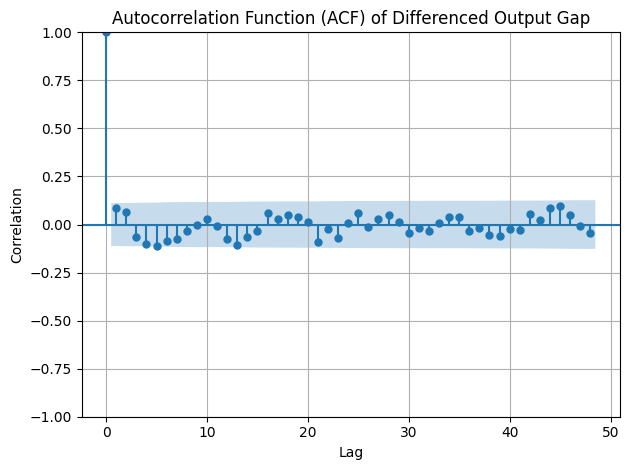

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 6))
plot_acf(output_gap_delta, lags=48, zero=True)
plt.title('Autocorrelation Function (ACF) of Differenced Output Gap')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.grid(True)
plt.tight_layout()


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

<Figure size 1200x600 with 0 Axes>

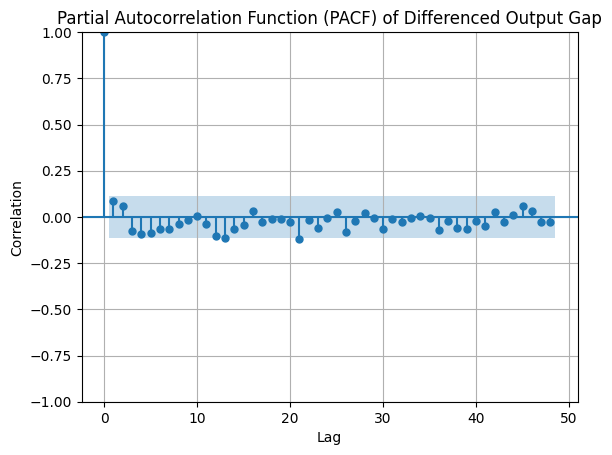

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 6))
plot_pacf(output_gap_delta, lags=48, zero=True)
plt.title('Partial Autocorrelation Function (PACF) of Differenced Output Gap')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.grid(True)
plt.tight_layout

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

def compare_arima_models(
    y,
    p_values=range(0, 5),
    d_values=[0],
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="c"
):
    """
    Fit multiple ARIMA(p,d,q) models and compare by AIC, BIC, HQIC,
    log-likelihood, and residual Ljung-Box p-value.

    Parameters
    ----------
    y : pd.Series or array-like
        Time series.
    p_values, d_values, q_values : iterable
        Candidate ARIMA orders.
    max_ljungbox_lag : int
        Lag used for residual autocorrelation test.
    trend : str
        'c' for constant, 'n' for no constant.

    Returns
    -------
    pd.DataFrame
        Model comparison table sorted by BIC.
    """

    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                # Skip degenerate ARIMA(0,0,0) if desired
                # if order == (0, 0, 0):
                #     continue

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")

                        model = ARIMA(
                            y,
                            order=order,
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )

                        fit = model.fit()

                    resid = fit.resid.dropna() if hasattr(fit.resid, "dropna") else fit.resid

                    lb = acorr_ljungbox(
                        resid,
                        lags=[max_ljungbox_lag],
                        return_df=True
                    )

                    lb_pvalue = lb["lb_pvalue"].iloc[0]

                    results.append({
                        "order": order,
                        "p": p,
                        "d": d,
                        "q": q,
                        "aic": fit.aic,
                        "bic": fit.bic,
                        "hqic": fit.hqic,
                        "loglik": fit.llf,
                        "ljungbox_p": lb_pvalue,
                        "converged": fit.mle_retvals.get("converged", None),
                    })

                except Exception as e:
                    results.append({
                        "order": order,
                        "p": p,
                        "d": d,
                        "q": q,
                        "aic": None,
                        "bic": None,
                        "hqic": None,
                        "loglik": None,
                        "ljungbox_p": None,
                        "converged": False,
                        "error": str(e)
                    })

    table = pd.DataFrame(results)

    table = table.dropna(subset=["aic", "bic"]).sort_values("bic")

    return table

In [ ]:
comparison = compare_arima_models(
    output_gap_delta,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="c"
)

In [ ]:
cols = ["order", "aic", "bic", "hqic", "loglik", "ljungbox_p", "converged"]

comparison_clean = comparison[comparison["converged"] == True].copy()
comparison_clean.head(7)

,order,p,d,q,aic,bic,hqic,loglik,ljungbox_p,converged,error
13,"(1, 0, 3)",1,0,3,877.695149,899.997315,886.616537,-432.847574,0.992775,True,NaN
14,"(1, 0, 4)",1,0,4,874.698612,900.694742,885.098828,-430.349306,0.985598,True,NaN
23,"(2, 0, 3)",2,0,3,879.694577,905.713771,890.102864,-432.847289,0.992799,True,NaN
41,"(4, 0, 1)",4,0,1,881.702694,907.721888,892.110981,-433.851347,0.998894,True,NaN
42,"(4, 0, 2)",4,0,2,879.805361,909.541583,891.700546,-431.902681,0.997267,True,NaN
12,"(1, 0, 2)",1,0,2,891.693232,910.294791,899.133465,-440.846616,0.467339,True,NaN
22,"(2, 0, 2)",2,0,2,888.711073,911.032944,897.639353,-438.355536,0.694179,True,NaN


                               SARIMAX Results                                
Dep. Variable:       output_gap_delta   No. Observations:                  308
Model:                 ARIMA(1, 0, 3)   Log Likelihood                -432.848
Date:                Tue, 19 May 2026   AIC                            877.695
Time:                        14:57:06   BIC                            899.997
Sample:                    04-01-1949   HQIC                           886.617
                         - 01-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0083      0.011     -0.748      0.455      -0.030       0.013
ar.L1          0.8166      0.056     14.624      0.000       0.707       0.926
ma.L1         -0.8182     64.374     -0.013      0.9

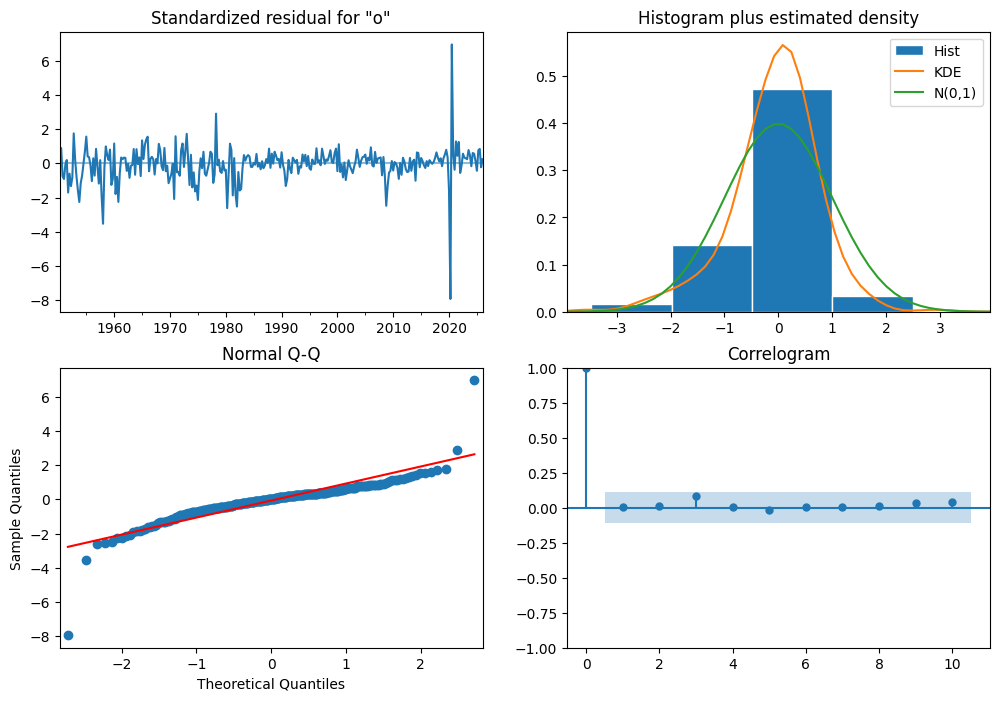

In [ ]:
best_bic_order = comparison_clean.sort_values("bic").iloc[0]["order"]

best_fit = ARIMA(
    output_gap_delta,
    order=best_bic_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(best_fit.summary())
best_fit.plot_diagnostics(figsize=(12, 8));

In [ ]:
comparison_growth = compare_arima_models(
    real_gdp_growth,
    p_values=range(0, 5),
    d_values=range(0, 2),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="c"
)

In [ ]:
comparison_growth_clean = comparison_growth[comparison_growth["converged"] == True].copy()
comparison_growth_clean.head(7)

,order,p,d,q,aic,bic,hqic,loglik,ljungbox_p,converged,error
13,"(1, 0, 3)",1,0,3,911.810420,934.112586,920.731808,-449.905210,0.994017,True,NaN
14,"(1, 0, 4)",1,0,4,910.897112,936.893241,921.297327,-448.448556,0.995610,True,NaN
41,"(4, 0, 1)",4,0,1,912.718067,938.737261,923.126353,-449.359033,0.998141,True,NaN
3,"(0, 0, 3)",0,0,3,920.549095,939.134233,927.983585,-455.274547,0.988630,True,NaN
23,"(2, 0, 3)",2,0,3,913.255514,939.274708,923.663801,-449.627757,0.995448,True,NaN
4,"(0, 0, 4)",0,0,4,917.510035,939.792432,926.424506,-452.755018,0.986255,True,NaN
2,"(0, 0, 2)",0,0,2,926.539343,941.420590,932.491530,-459.269672,0.993324,True,NaN


/tmp/ipykernel_455/851169359.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  log_lik = -0.5 * ((y[t_step] - alpha * particles) / tau) ** 2


RMSE: 0.8044070020189471


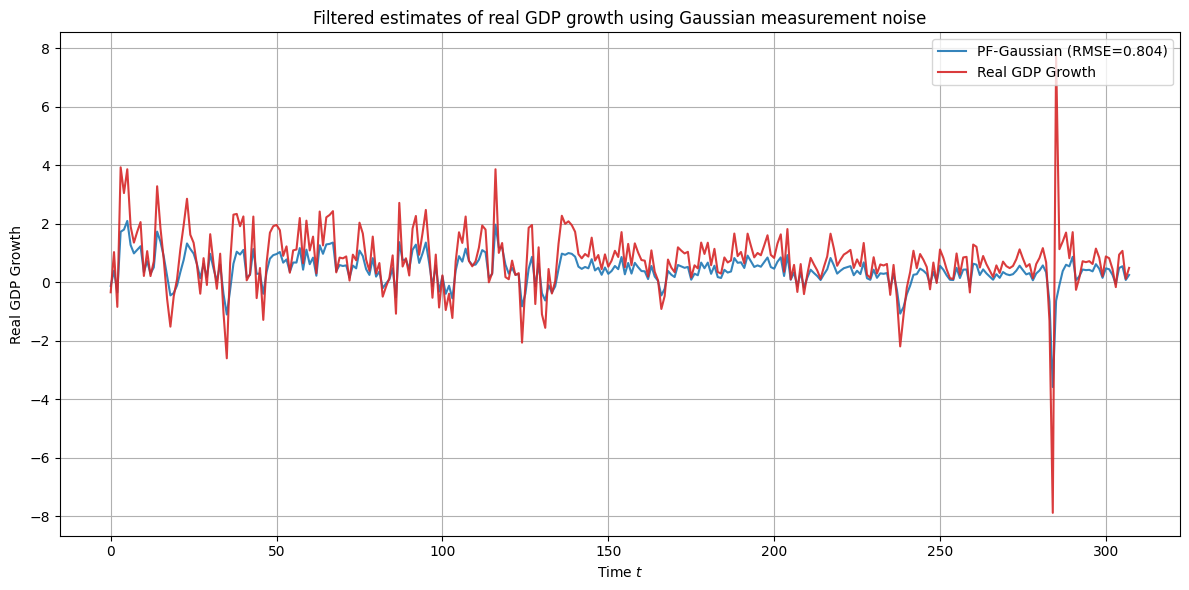

In [ ]:
# Particle Filter (Gaussian)

results_gdp = particle_filter(real_gdp_growth, phi = 0.9, alpha = 1.5, sigma = 0.5, tau = 1.0, N_particles=10000)
rmse = np.sqrt(np.mean((results_gdp[0] - real_gdp_growth) ** 2))
print(f"RMSE: {rmse}")

time_steps = np.arange(len(real_gdp_growth))

plt.figure(figsize=(12, 6))
plt.plot(time_steps, results_gdp[0], label=f"PF-Gaussian (RMSE={rmse:.3f})",
         color="tab:blue", alpha=0.9)
plt.plot(time_steps, real_gdp_growth, label="Real GDP Growth", color = "tab:red", alpha=0.9)
plt.xlabel("Time $t$")
plt.ylabel("Real GDP Growth")
plt.title("Filtered estimates of real GDP growth using Gaussian measurement noise")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()

/tmp/ipykernel_455/63734328.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  residuals = y[t_step] - alpha * particles


RMSE: 0.7375948597718256
RMSE: 0.48261099871010193


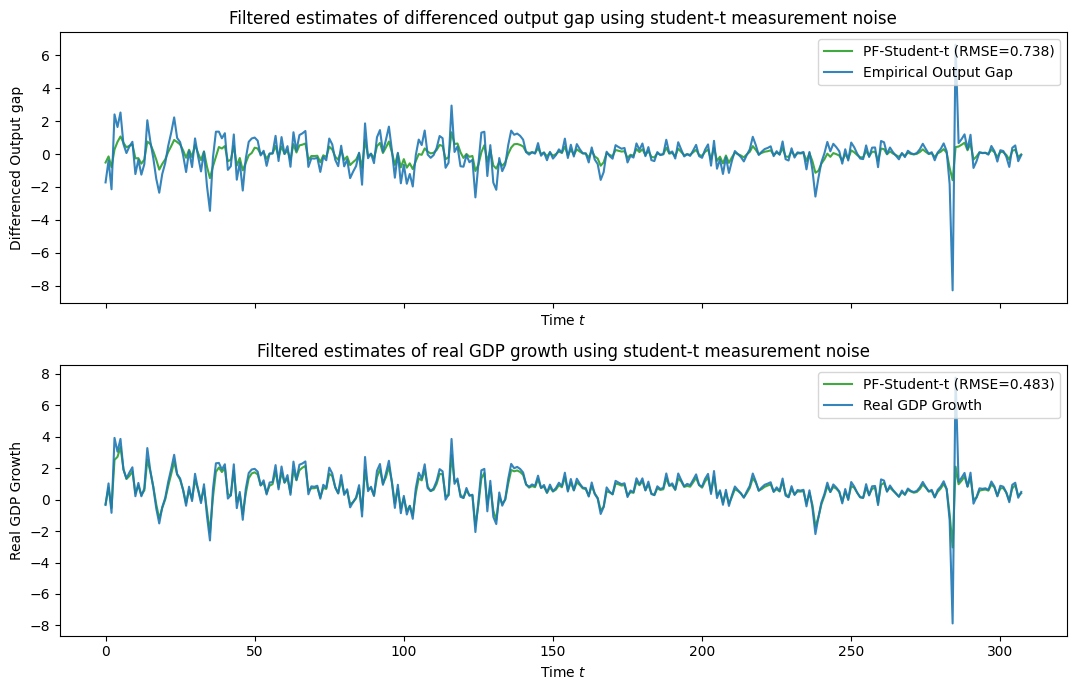

In [ ]:
# Particle Filter (Student t)

results = particle_filter_student_t(output_gap_delta, phi = 0.9, alpha = 1.5, sigma = 0.5, scale = 1.0, df = 4, N_particles=10000)
rmse = np.sqrt(np.mean((results[0] - output_gap_delta) ** 2))
print(f"RMSE: {rmse}")
time_steps = np.arange(len(output_gap_delta))

results_gdp_t = particle_filter_student_t(real_gdp_growth, phi = 0.9, alpha = 1.1, sigma = 1.2, scale = 0.50, df = 4, N_particles=10000)
rmse_gdp = np.sqrt(np.mean((results_gdp_t[0] - real_gdp_growth) ** 2))
print(f"RMSE: {rmse_gdp}")

time_steps_gdp = np.arange(len(real_gdp_growth))

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(time_steps, results[0],     label=f"PF-Student-t (RMSE={rmse:.3f})",
             color="tab:green", alpha=0.9)
axes[0].plot(time_steps, output_gap_delta, label="Empirical Output Gap", color = "tab:blue", alpha=0.9)
axes[0].set_xlabel("Time $t$")
axes[0].set_ylabel("Differenced Output gap")
axes[0].set_title("Filtered estimates of differenced output gap using student-t measurement noise")
axes[0].legend(loc="upper right")

axes[1].plot(time_steps_gdp, results_gdp_t[0],     label=f"PF-Student-t (RMSE={rmse_gdp:.3f})",
             color="tab:green", alpha=0.9)
axes[1].plot(time_steps_gdp, real_gdp_growth, label="Real GDP Growth", color = "tab:blue", alpha=0.9)
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel("Real GDP Growth")
axes[1].set_title("Filtered estimates of real GDP growth using student-t measurement noise")
axes[1].legend(loc="upper right")

plt.tight_layout()


In [ ]:
len(results_gdp[1][0])

10000

/tmp/ipykernel_455/851169359.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  log_lik = -0.5 * ((y[t_step] - alpha * particles) / tau) ** 2
/tmp/ipykernel_455/63734328.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  residuals = y[t_step] - alpha * particles


RMSE for Gaussian: 0.8180688153043173
RMSE for t-student: 0.8449860321051084


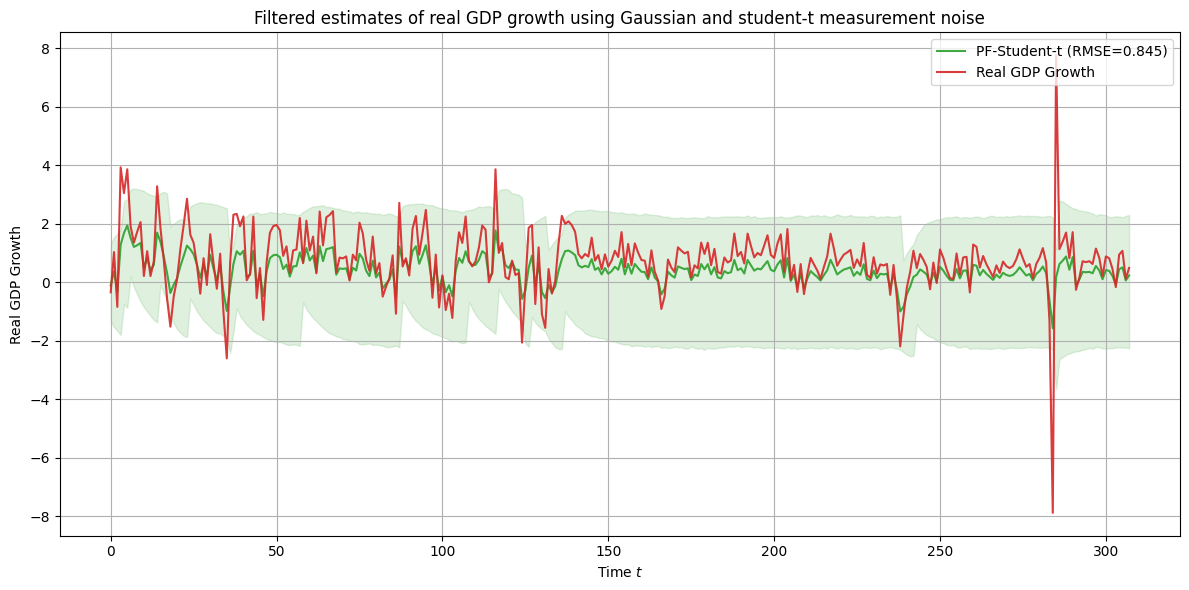

In [ ]:
# compare Gaussian and t for real_gdp_growth

results_gdp = particle_filter(real_gdp_growth, phi = 0.9, alpha = 1.5, sigma = 0.5, tau = 1.0, N_particles=10000)
results_gdp_t = particle_filter_student_t(real_gdp_growth, phi = 0.9, alpha = 1.5, sigma = 0.5, scale = 1.0, df = 4, N_particles = 10000)
rmse = np.sqrt(np.mean((results_gdp[0] - real_gdp_growth) ** 2))
rmse_t = np.sqrt(np.mean((results_gdp_t[0] - real_gdp_growth) ** 2))
print(f"RMSE for Gaussian: {rmse}")
print(f"RMSE for t-student: {rmse_t}")

time_steps_gdp = np.arange(len(real_gdp_growth))

# confidence interval estimates from particle filter
particle_gdp = np.array(results_gdp[1])
particle_gdp_t = np.array(results_gdp_t[1])


plt.figure(figsize=(12, 6))
# plt.plot(time_steps_gdp, results_gdp[0], label=f"PF-Gaussian (RMSE={rmse:.3f})", color="tab:blue", alpha=0.9)
# plt.fill_between(time_steps_gdp, np.quantile(particle_gdp, 0.025, axis=1), np.quantile(particle_gdp, 0.975, axis=1), color="tab:blue", alpha= 0.15)

plt.plot(time_steps_gdp, results_gdp_t[0], label=f"PF-Student-t (RMSE={rmse_t:.3f})", color="tab:green", alpha=0.9)
plt.fill_between(time_steps_gdp, np.quantile(particle_gdp_t, 0.025, axis=1), np.quantile(particle_gdp_t, 0.975, axis=1), color="tab:green", alpha= 0.15)

plt.plot(time_steps_gdp, real_gdp_growth, label="Real GDP Growth", color = "tab:red", alpha=0.9)

plt.xlabel("Time $t$")
plt.ylabel("Real GDP Growth")
plt.title("Filtered estimates of real GDP growth using Gaussian and student-t measurement noise")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()

An alternative way to capture large-deviations would be to consider a regime change model with regime variable $s_t$. Here, we ignore the previous regression results showing that models with MA order 2 or 3 may fit the data better.

$$
\mathbb P(s_t=j\mid s_{t-1}=i)=p_{ij},
\qquad i,j\in\{1,2\}.
$$

$$
x_t= \phi x_{t-1}+\sigma_{s_t}\epsilon_t,
\qquad \epsilon_t\sim N(0,1).
$$

$$
y_t=x_t+ \tau \nu_t
\qquad \nu_t\sim N(0,1).
$$

The parameter vector is

$$
\theta = [p_{11}, p_{22},  \phi, \sigma_1, \sigma_2, \tau]
$$

and has dimension 6.

(ChatGPT)

# Regime-Switching State-Space Model: Density and Conditional Density Formulas

To capture large-deviation behavior, consider a regime-switching state-space model with latent regime variable $s_t \in \{1,2\}$. Here, we ignore the previous regression results showing that models with MA order 2 or 3 may fit the data better.

The model is

$$
\mathbb P(s_t=j\mid s_{t-1}=i)=p_{ij},
\qquad i,j\in\{1,2\}.
$$

$$
x_t= \phi x_{t-1}+\sigma_{s_t}\epsilon_t,
\qquad \epsilon_t\sim N(0,1).
$$

$$
y_t=x_t+ \tau \nu_t,
\qquad \nu_t\sim N(0,1).
$$

The parameter vector is

$$
\theta = [p_{11}, p_{22}, \phi, \sigma_1, \sigma_2, \tau],
$$

with dimension $6$.

The parameter constraints are

$$
0 < p_{11},p_{22}<1,
\qquad
\sigma_1,\sigma_2,\tau>0.
$$

Usually we also impose

$$
|\phi|<1
$$

if we want the latent output-gap state to be stationary in each regime.

---

## 1. Regime transition probabilities

The transition matrix is

$$
P
=
\begin{pmatrix}
p_{11} & p_{12} \\
p_{21} & p_{22}
\end{pmatrix}
=
\begin{pmatrix}
p_{11} & 1-p_{11} \\
1-p_{22} & p_{22}
\end{pmatrix}.
$$

Therefore,

$$
p_{12}=1-p_{11},
\qquad
p_{21}=1-p_{22}.
$$

For a regime path $s_{0:T}=(s_0,\dots,s_T)$, the regime path probability is

$$
p_\theta(s_{0:T})
=
p(s_0)\prod_{t=1}^T p_{s_{t-1},s_t}.
$$

If we initialize the regime chain from its stationary distribution, then

$$
\mathbb P(s_0=1)
=
\frac{1-p_{22}}{2-p_{11}-p_{22}},
$$

and

$$
\mathbb P(s_0=2)
=
\frac{1-p_{11}}{2-p_{11}-p_{22}}.
$$

---

## 2. State transition density

Conditional on $s_t=j$ and $x_{t-1}$,

$$
x_t
=
\phi x_{t-1}+\sigma_j\epsilon_t,
\qquad
\epsilon_t\sim N(0,1).
$$

Therefore,

$$
x_t\mid x_{t-1},s_t=j
\sim
N(\phi x_{t-1},\sigma_j^2).
$$

The transition density is

$$
p_\theta(x_t\mid x_{t-1},s_t=j)
=
\frac{1}{\sqrt{2\pi\sigma_j^2}}
\exp\left[
-\frac{
(x_t-\phi x_{t-1})^2
}{
2\sigma_j^2
}
\right].
$$

Equivalently, using the Gaussian density notation

$$
\varphi_v(z)
=
\frac{1}{\sqrt{2\pi v}}
\exp\left(-\frac{z^2}{2v}\right),
$$

we can write

$$
p_\theta(x_t\mid x_{t-1},s_t=j)
=
\varphi_{\sigma_j^2}
\left(
x_t-\phi x_{t-1}
\right).
$$

---

## 3. Observation density

The observation equation is

$$
y_t=x_t+\tau\nu_t,
\qquad
\nu_t\sim N(0,1).
$$

Thus,

$$
y_t\mid x_t
\sim
N(x_t,\tau^2).
$$

The observation density is

$$
p_\theta(y_t\mid x_t)
=
\frac{1}{\sqrt{2\pi\tau^2}}
\exp\left[
-\frac{(y_t-x_t)^2}{2\tau^2}
\right].
$$

Equivalently,

$$
p_\theta(y_t\mid x_t)
=
\varphi_{\tau^2}(y_t-x_t).
$$

Since the observation equation does not depend directly on $s_t$, we have

$$
p_\theta(y_t\mid x_t,s_t)
=
p_\theta(y_t\mid x_t)
=
\varphi_{\tau^2}(y_t-x_t).
$$

---

## 4. One-step joint density

For $t\geq 1$, conditional on $(x_{t-1},s_{t-1}=i)$, the joint density of $(s_t,x_t,y_t)$ is

$$
p_\theta(s_t=j,x_t,y_t\mid x_{t-1},s_{t-1}=i)
=
p_{ij}
p_\theta(x_t\mid x_{t-1},s_t=j)
p_\theta(y_t\mid x_t).
$$

Substituting the Gaussian densities,

$$
p_\theta(s_t=j,x_t,y_t\mid x_{t-1},s_{t-1}=i)
=
p_{ij}
\varphi_{\sigma_j^2}
\left(
x_t-\phi x_{t-1}
\right)
\varphi_{\tau^2}
\left(
y_t-x_t
\right).
$$

This is the main local density used for filtering.

---

## 5. Conditional density of $y_t$ given previous state and proposed regime

We can integrate out $x_t$.

Given $x_{t-1}$ and $s_t=j$,

$$
x_t\mid x_{t-1},s_t=j
\sim
N(\phi x_{t-1},\sigma_j^2).
$$

Given $x_t$,

$$
y_t\mid x_t
\sim
N(x_t,\tau^2).
$$

Therefore, by Gaussian convolution,

$$
y_t\mid x_{t-1},s_t=j
\sim
N(\phi x_{t-1},\sigma_j^2+\tau^2).
$$

Hence,

$$
p_\theta(y_t\mid x_{t-1},s_t=j)
=
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right).
$$

This density is useful for constructing an efficient particle-filter proposal.

---

## 6. Conditional regime probability after observing $y_t$

Suppose the previous regime is $s_{t-1}=i$ and previous state is $x_{t-1}$. Then

$$
p_\theta(s_t=j\mid y_t,x_{t-1},s_{t-1}=i)
\propto
p_{ij}
p_\theta(y_t\mid x_{t-1},s_t=j).
$$

Using the formula above,

$$
p_\theta(s_t=j\mid y_t,x_{t-1},s_{t-1}=i)
=
\frac{
p_{ij}
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}{
\sum_{k=1}^2
p_{ik}
\varphi_{\sigma_k^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}.
$$

This formula shows how a large observation can increase the posterior probability of the high-volatility regime. If, for example,

$$
\sigma_2^2 \gg \sigma_1^2,
$$

then large deviations are more likely to be attributed to regime $2$.

---

## 7. Conditional density of $x_t$ given $y_t$, regime, and previous state

This is a Gaussian updating formula.

The prior is

$$
x_t\mid x_{t-1},s_t=j
\sim
N(m_t^{(j)},\sigma_j^2),
$$

where

$$
m_t^{(j)}=\phi x_{t-1}.
$$

The observation equation is

$$
y_t=x_t+\tau\nu_t,
\qquad
\nu_t\sim N(0,1).
$$

Thus,

$$
y_t\mid x_t
\sim
N(x_t,\tau^2).
$$

Therefore,

$$
x_t\mid y_t,x_{t-1},s_t=j
\sim
N(\bar m_t^{(j)},\bar V_j),
$$

where

$$
\bar V_j
=
\left(
\frac{1}{\sigma_j^2}
+
\frac{1}{\tau^2}
\right)^{-1},
$$

and

$$
\bar m_t^{(j)}
=
\bar V_j
\left(
\frac{\phi x_{t-1}}{\sigma_j^2}
+
\frac{y_t}{\tau^2}
\right).
$$

Equivalently,

$$
\bar m_t^{(j)}
=
\phi x_{t-1}
+
\frac{\sigma_j^2}{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right).
$$

This is the Kalman-style conditional update, conditional on the regime.

---

## 8. Complete-data joint density

Suppose the observed data are $y_{0:T}$ and the latent variables are

$$
x_{0:T}
=
(x_0,\dots,x_T),
\qquad
s_{0:T}
=
(s_0,\dots,s_T).
$$

The complete-data joint density is

$$
p_\theta(y_{0:T},x_{0:T},s_{0:T})
=
p(s_0)
p_\theta(x_0\mid s_0)
p_\theta(y_0\mid x_0)
\prod_{t=1}^T
p_{s_{t-1},s_t}
p_\theta(x_t\mid x_{t-1},s_t)
p_\theta(y_t\mid x_t).
$$

Substituting the Gaussian densities,

$$
p_\theta(y_{0:T},x_{0:T},s_{0:T})
=
p(s_0)
p_\theta(x_0\mid s_0)
\varphi_{\tau^2}(y_0-x_0)
\prod_{t=1}^T
p_{s_{t-1},s_t}
\varphi_{\sigma_{s_t}^2}
\left(
x_t-\phi x_{t-1}
\right)
\varphi_{\tau^2}
\left(
y_t-x_t
\right).
$$

An initial distribution for $x_0$ must be specified. A simple choice is

$$
x_0\sim N(0,V_0).
$$

If the model is initialized approximately from a stationary regime mixture, one may use a large diffuse $V_0$, or a regime-dependent approximation such as

$$
x_0\mid s_0=j
\sim
N\left(0,\frac{\sigma_j^2}{1-\phi^2}\right),
$$

although this is only approximate because future regimes can switch.

---

## 9. Complete-data log-density

Ignoring constants that do not depend on $\theta$, the complete-data log-density is

$$
\log p_\theta(y_{0:T},x_{0:T},s_{0:T})
=
\log p(s_0)
+
\log p_\theta(x_0\mid s_0)
+
\sum_{t=1}^T \log p_{s_{t-1},s_t}
$$

$$
-
\frac12
\sum_{t=1}^T
\left[
\log \sigma_{s_t}^2
+
\frac{
(x_t-\phi x_{t-1})^2
}{
\sigma_{s_t}^2
}
\right]
-
\frac12
\sum_{t=0}^T
\left[
\log \tau^2
+
\frac{(y_t-x_t)^2}{\tau^2}
\right].
$$

If $x_0$ has a parameter-dependent distribution, its log-density should also be included explicitly.

---

## 10. Filtering recursion

The filtering object is

$$
\pi_t^j(x_t)
=
p_\theta(x_t,s_t=j\mid y_{0:t}).
$$

Suppose at time $t-1$ we have

$$
\pi_{t-1}^i(x_{t-1})
=
p_\theta(x_{t-1},s_{t-1}=i\mid y_{0:t-1}).
$$

The prediction-update step is

$$
\widetilde \pi_t^j(x_t)
=
p_\theta(y_t\mid x_t)
\sum_{i=1}^2
\int
p_{ij}
p_\theta(x_t\mid x_{t-1},s_t=j)
\pi_{t-1}^i(x_{t-1})
\,dx_{t-1}.
$$

Substituting the Gaussian densities,

$$
\widetilde \pi_t^j(x_t)
=
\varphi_{\tau^2}(y_t-x_t)
\sum_{i=1}^2
\int
p_{ij}
\varphi_{\sigma_j^2}
\left(
x_t-\phi x_{t-1}
\right)
\pi_{t-1}^i(x_{t-1})
\,dx_{t-1}.
$$

The normalizing constant is the predictive likelihood contribution

$$
p_\theta(y_t\mid y_{0:t-1})
=
\sum_{j=1}^2
\int
\widetilde \pi_t^j(x_t)
\,dx_t.
$$

The normalized filtering density is

$$
\pi_t^j(x_t)
=
\frac{
\widetilde \pi_t^j(x_t)
}{
p_\theta(y_t\mid y_{0:t-1})
}.
$$

The full likelihood is

$$
p_\theta(y_{0:T})
=
p_\theta(y_0)
\prod_{t=1}^T
p_\theta(y_t\mid y_{0:t-1}),
$$

and the log-likelihood is

$$
\log p_\theta(y_{0:T})
=
\log p_\theta(y_0)
+
\sum_{t=1}^T
\log p_\theta(y_t\mid y_{0:t-1}).
$$

---

## 11. Bootstrap particle filter

A bootstrap particle filter carries particles

$$
(x_t^{(n)},s_t^{(n)}),
\qquad n=1,\dots,N.
$$

Suppose at time $t-1$ we have particles

$$
(x_{t-1}^{(n)},s_{t-1}^{(n)}).
$$

For each particle:

### Step 1: Propagate the regime

Sample

$$
s_t^{(n)}
\sim
\mathbb P(s_t\mid s_{t-1}^{(n)}).
$$

That is,

$$
\mathbb P(s_t^{(n)}=j\mid s_{t-1}^{(n)}=i)
=
p_{ij}.
$$

### Step 2: Propagate the latent state

Sample

$$
x_t^{(n)}
\sim
N\left(
\phi x_{t-1}^{(n)},
\sigma_{s_t^{(n)}}^2
\right).
$$

### Step 3: Compute the observation weight

The unnormalized weight is

$$
w_t^{(n)}
=
p_\theta(y_t\mid x_t^{(n)})
=
\varphi_{\tau^2}
\left(
y_t-x_t^{(n)}
\right).
$$

### Step 4: Normalize weights

$$
W_t^{(n)}
=
\frac{w_t^{(n)}}{\sum_{m=1}^N w_t^{(m)}}.
$$

### Step 5: Estimate regime probabilities

The filtered probability of regime $j$ is approximated by

$$
\widehat{\mathbb P}(s_t=j\mid y_{0:t})
=
\sum_{n=1}^N
W_t^{(n)}
\mathbf 1_{\{s_t^{(n)}=j\}}.
$$

### Step 6: Estimate the filtering mean of the latent state

$$
\widehat{\mathbb E}[x_t\mid y_{0:t}]
=
\sum_{n=1}^N
W_t^{(n)}x_t^{(n)}.
$$

### Step 7: Estimate the likelihood contribution

For the bootstrap filter, the likelihood contribution is estimated by

$$
\widehat p_\theta(y_t\mid y_{0:t-1})
=
\frac{1}{N}
\sum_{n=1}^N
w_t^{(n)}
$$

when particles before weighting have equal weights.

Thus,

$$
\widehat p_\theta(y_{0:T})
=
\prod_{t=0}^T
\left(
\frac{1}{N}
\sum_{n=1}^N
w_t^{(n)}
\right),
$$

and

$$
\log \widehat p_\theta(y_{0:T})
=
\sum_{t=0}^T
\log
\left(
\frac{1}{N}
\sum_{n=1}^N
w_t^{(n)}
\right).
$$

---

## 12. Optimal proposal particle filter

The bootstrap particle filter proposes $s_t$ and $x_t$ before looking at $y_t$. A more efficient proposal uses $y_t$ when proposing the regime and state.

Given $(x_{t-1},s_{t-1}=i)$, first sample $s_t=j$ from

$$
p_\theta(s_t=j\mid y_t,x_{t-1},s_{t-1}=i)
=
\frac{
p_{ij}
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}{
\sum_{k=1}^2
p_{ik}
\varphi_{\sigma_k^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}.
$$

Then sample $x_t$ from

$$
x_t\mid y_t,x_{t-1},s_t=j
\sim
N(\bar m_t^{(j)},\bar V_j),
$$

where

$$
\bar V_j
=
\left(
\frac{1}{\sigma_j^2}
+
\frac{1}{\tau^2}
\right)^{-1},
$$

and

$$
\bar m_t^{(j)}
=
\bar V_j
\left(
\frac{\phi x_{t-1}}{\sigma_j^2}
+
\frac{y_t}{\tau^2}
\right).
$$

Equivalently,

$$
\bar m_t^{(j)}
=
\phi x_{t-1}
+
\frac{\sigma_j^2}{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right).
$$

The corresponding predictive likelihood term for particle $n$ is

$$
p_\theta(y_t\mid x_{t-1}^{(n)},s_{t-1}^{(n)}=i)
=
\sum_{j=1}^2
p_{ij}
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}^{(n)}
\right).
$$

This proposal is usually more efficient than the bootstrap proposal because it uses the current observation $y_t$ before proposing the new state.

---

## 13. Why this model captures large deviations

Conditional on the regime, the state innovation is Gaussian:

$$
x_t-\phi x_{t-1}\mid s_t=j
\sim
N(0,\sigma_j^2).
$$

Unconditionally, the innovation distribution is approximately a mixture of Gaussians:

$$
x_t-\phi x_{t-1}
\sim
\pi_1 N(0,\sigma_1^2)
+
\pi_2 N(0,\sigma_2^2),
$$

where $\pi_j$ is the marginal probability of regime $j$.

If

$$
\sigma_2^2 \gg \sigma_1^2,
$$

then the unconditional innovation distribution has heavier tails than a single Gaussian distribution.

Thus, the model preserves conditional Gaussianity while allowing heavy-tailed unconditional behavior.

In words:

$$
\text{normal regime}
\Rightarrow
\text{small shocks},
$$

while

$$
\text{crisis regime}
\Rightarrow
\text{large shocks}.
$$

This is why a regime-switching model can capture large deviations such as crisis or COVID-period output-gap movements more naturally than a single-regime Gaussian state-space model.

---

## 14. Important simplifications and caveats

This simplified model does not attempt to match the empirical ARMA$(1,2)$ or ARMA$(1,3)$ behavior suggested by the reduced-form ARIMA fits. It is focused on tail behavior.

The model implies that the observed process is driven by a persistent latent AR(1) state with regime-dependent innovation variance and independent Gaussian measurement noise.

If the regime were fixed, the model

$$
x_t=\phi x_{t-1}+\sigma\epsilon_t,
$$

$$
y_t=x_t+\tau\nu_t
$$

would have an ARMA$(1,1)$ reduced form.

Indeed,

$$
y_t-\phi y_{t-1}
=
\sigma\epsilon_t
+
\tau\nu_t
-
\phi\tau\nu_{t-1}.
$$

Therefore,

$$
(1-\phi L)y_t
=
\sigma\epsilon_t
+
\tau(1-\phi L)\nu_t.
$$

This is ARMA$(1,1)$-type behavior.

With regime switching, the model is no longer a standard linear Gaussian ARMA model because the innovation variance changes over time according to $s_t$. However, it preserves the intuition that $\phi$ governs persistence while the regimes govern large deviations.

Main caveats:

1. The regime labels are not identified unless we impose an ordering such as

   $$
   \sigma_2>\sigma_1.
   $$

2. If there are very few crisis observations, the high-volatility regime may be weakly estimated.

3. The model captures heavy tails through volatility switching, but it does not capture delayed measurement effects or higher MA order.

4. If $\tau$ is too large relative to $\sigma_j$, the model may attribute large movements to measurement noise rather than regime-switching state innovations.

5. If $\phi$ is close to one, the latent process is highly persistent and estimation may be numerically difficult.

---

## 15. Summary

The simplified regime-switching state-space model is

$$
s_t\mid s_{t-1}\sim P,
$$

$$
x_t\mid x_{t-1},s_t=j
\sim
N(\phi x_{t-1},\sigma_j^2),
$$

$$
y_t\mid x_t
\sim
N(x_t,\tau^2).
$$

The key densities are

$$
p_\theta(x_t\mid x_{t-1},s_t=j)
=
\varphi_{\sigma_j^2}
\left(
x_t-\phi x_{t-1}
\right),
$$

$$
p_\theta(y_t\mid x_t)
=
\varphi_{\tau^2}
\left(
y_t-x_t
\right),
$$

and

$$
p_\theta(y_t\mid x_{t-1},s_t=j)
=
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right).
$$

The regime-posterior update is

$$
p_\theta(s_t=j\mid y_t,x_{t-1},s_{t-1}=i)
=
\frac{
p_{ij}
\varphi_{\sigma_j^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}{
\sum_{k=1}^2
p_{ik}
\varphi_{\sigma_k^2+\tau^2}
\left(
y_t-\phi x_{t-1}
\right)
}.
$$

The state-posterior update conditional on regime is

$$
x_t\mid y_t,x_{t-1},s_t=j
\sim
N(\bar m_t^{(j)},\bar V_j),
$$

where

$$
\bar V_j
=
\left(
\frac{1}{\sigma_j^2}
+
\frac{1}{\tau^2}
\right)^{-1},
$$

and

$$
\bar m_t^{(j)}
=
\bar V_j
\left(
\frac{\phi x_{t-1}}{\sigma_j^2}
+
\frac{y_t}{\tau^2}
\right).
$$

In [ ]:
def log_normal_pdf(y, mean, sd):
    """
    Log density of N(mean, sd^2), vectorized.
    """
    return -0.5 * np.log(2.0 * np.pi * sd**2) - 0.5 * ((y - mean) / sd) ** 2


def logsumexp(a):
    """
    Numerically stable log(sum(exp(a))).
    """
    a_max = np.max(a)
    return a_max + np.log(np.sum(np.exp(a - a_max)))


def systematic_resample(weights, rng):
    """
    Systematic resampling.

    Parameters
    ----------
    weights : array, shape (N,)
        Normalized particle weights.
    rng : np.random.Generator

    Returns
    -------
    indices : array, shape (N,)
        Resampled ancestor indices.
    """
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N

    cumulative_sum = np.cumsum(weights)
    indices = np.zeros(N, dtype=int)

    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indices[i] = j
            i += 1
        else:
            j += 1

    return indices


def stationary_regime_probs(p11, p22):
    """
    Stationary distribution of a two-state Markov chain.

    P = [[p11, 1-p11],
         [1-p22, p22]]
    """
    denom = 2.0 - p11 - p22
    pi1 = (1.0 - p22) / denom
    pi2 = (1.0 - p11) / denom
    return np.array([pi1, pi2])


def bootstrap_pf_regime_switching(
    y,
    theta,
    N_particles=1000,
    seed=0,
    resample_threshold=0.5,
    x0_mean=0.0,
    x0_sd=None,
    store_particles=False,
):
    """
    Bootstrap particle filter for the regime-switching state-space model:

        P(s_t = j | s_{t-1} = i) = p_ij

        x_t = phi x_{t-1} + sigma_{s_t} eps_t,
        eps_t ~ N(0, 1)

        y_t = x_t + tau nu_t,
        nu_t ~ N(0, 1)

    Parameters
    ----------
    y : array-like, shape (T,)
        Observed time series.

    theta : array-like, shape (6,)
        Parameter vector:
            [p11, p22, phi, sigma1, sigma2, tau]

    N_particles : int
        Number of particles.

    seed : int
        Random seed.

    resample_threshold : float
        Resample when ESS < resample_threshold * N_particles.
        Use 1.0 to resample every period.

    x0_mean : float
        Initial mean for x_0.

    x0_sd : float or None
        Initial standard deviation for x_0.
        If None, uses a rough stationary mixture approximation.

    store_particles : bool
        If True, stores particle arrays through time.

    Returns
    -------
    out : dict
        Contains:
            loglik : particle filter log-likelihood estimate
            x_filter_mean : filtered mean E[x_t | y_0:t]
            x_filter_var : filtered variance Var[x_t | y_0:t]
            regime_probs : filtered probabilities P(s_t = regime | y_0:t)
            ess : effective sample size over time
            particles_x : optional, shape (T, N)
            particles_s : optional, shape (T, N)
            weights : optional, shape (T, N)
    """
    y = np.asarray(y, dtype=float)
    T = len(y)

    p11, p22, phi, sigma1, sigma2, tau = theta

    # Basic parameter checks
    if not (0.0 < p11 < 1.0 and 0.0 < p22 < 1.0):
        raise ValueError("p11 and p22 must be in (0, 1).")
    if sigma1 <= 0.0 or sigma2 <= 0.0 or tau <= 0.0:
        raise ValueError("sigma1, sigma2, and tau must be positive.")

    rng = np.random.default_rng(seed)

    sigmas = np.array([sigma1, sigma2])

    P = np.array([
        [p11, 1.0 - p11],
        [1.0 - p22, p22],
    ])

    # Initial regime distribution
    pi_s = stationary_regime_probs(p11, p22)

    # Initial state distribution
    if x0_sd is None:
        # Rough stationary mixture variance approximation.
        # Since regimes switch, this is not exact, but works as a practical initialization.
        avg_sigma2 = pi_s[0] * sigma1**2 + pi_s[1] * sigma2**2
        if abs(phi) < 1.0:
            x0_sd = np.sqrt(avg_sigma2 / (1.0 - phi**2))
        else:
            x0_sd = 10.0 * np.sqrt(avg_sigma2)

    # Allocate outputs
    x_filter_mean = np.zeros(T)
    x_filter_var = np.zeros(T)
    regime_probs = np.zeros((T, 2))
    ess = np.zeros(T)

    if store_particles:
        particles_x = np.zeros((T, N_particles))
        particles_s = np.zeros((T, N_particles), dtype=int)
        weights_store = np.zeros((T, N_particles))
    else:
        particles_x = None
        particles_s = None
        weights_store = None

    # -----------------------------
    # Initialization at t = 0
    # -----------------------------
    s_particles = rng.choice(2, size=N_particles, p=pi_s)
    x_particles = rng.normal(x0_mean, x0_sd, size=N_particles)

    logw = log_normal_pdf(y[0], mean=x_particles, sd=tau)

    loglik = logsumexp(logw) - np.log(N_particles)

    # Normalize weights
    logw_norm = logw - logsumexp(logw)
    weights = np.exp(logw_norm)

    # Filtered estimates at t = 0
    x_filter_mean[0] = np.sum(weights * x_particles)
    x_filter_var[0] = np.sum(weights * (x_particles - x_filter_mean[0]) ** 2)

    regime_probs[0, 0] = np.sum(weights * (s_particles == 0))
    regime_probs[0, 1] = np.sum(weights * (s_particles == 1))

    ess[0] = 1.0 / np.sum(weights**2)

    if store_particles:
        particles_x[0] = x_particles
        particles_s[0] = s_particles
        weights_store[0] = weights

    # Resample after initialization if needed
    if ess[0] < resample_threshold * N_particles:
        ancestors = systematic_resample(weights, rng)
        x_particles = x_particles[ancestors]
        s_particles = s_particles[ancestors]
        weights = np.full(N_particles, 1.0 / N_particles)

    # -----------------------------
    # Recursive filtering
    # -----------------------------
    for t in range(1, T):

        # 1. Propagate regimes
        u = rng.random(N_particles)
        s_new = np.empty(N_particles, dtype=int)

        # If previous regime is 0, transition to 0 with prob p11.
        mask0 = (s_particles == 0)
        s_new[mask0] = (u[mask0] >= P[0, 0]).astype(int)

        # If previous regime is 1, transition to 0 with prob p21 = P[1,0].
        mask1 = ~mask0
        s_new[mask1] = (u[mask1] >= P[1, 0]).astype(int)

        s_particles = s_new

        # 2. Propagate latent state
        x_particles = (
            phi * x_particles
            + sigmas[s_particles] * rng.normal(size=N_particles)
        )

        # 3. Weight by observation likelihood p(y_t | x_t)
        logw = log_normal_pdf(y[t], mean=x_particles, sd=tau)

        # 4. Increment log-likelihood estimate
        loglik += logsumexp(logw) - np.log(N_particles)

        # 5. Normalize weights
        logw_norm = logw - logsumexp(logw)
        weights = np.exp(logw_norm)

        # 6. Store filtered estimates before resampling
        x_filter_mean[t] = np.sum(weights * x_particles)
        x_filter_var[t] = np.sum(weights * (x_particles - x_filter_mean[t]) ** 2)

        regime_probs[t, 0] = np.sum(weights * (s_particles == 0))
        regime_probs[t, 1] = np.sum(weights * (s_particles == 1))

        ess[t] = 1.0 / np.sum(weights**2)

        if store_particles:
            particles_x[t] = x_particles
            particles_s[t] = s_particles
            weights_store[t] = weights

        # 7. Resample if ESS is low
        if ess[t] < resample_threshold * N_particles:
            ancestors = systematic_resample(weights, rng)
            x_particles = x_particles[ancestors]
            s_particles = s_particles[ancestors]
            weights = np.full(N_particles, 1.0 / N_particles)

    return {
        "loglik": loglik,
        "x_filter_mean": x_filter_mean,
        "x_filter_var": x_filter_var,
        "x_filter_sd": np.sqrt(x_filter_var),
        "regime_probs": regime_probs,
        "ess": ess,
        "particles_x": particles_x,
        "particles_s": particles_s,
        "weights": weights_store,
    }

In [ ]:
theta = np.array([
    0.95,  # p11: normal regime persistence
    0.80,  # p22: crisis regime persistence
    0.90,  # phi: latent output-gap persistence
    0.40,  # sigma1: normal state shock volatility
    2.00,  # sigma2: crisis state shock volatility
    0.20,  # tau: measurement noise
])

out = bootstrap_pf_regime_switching(
    y=real_gdp_growth.values,
    theta=theta,
    N_particles=10000,
    seed=123,
    resample_threshold=0.5,
    store_particles=False,
)

print("PF log-likelihood:", out["loglik"])

PF log-likelihood: -1060.8766264489195


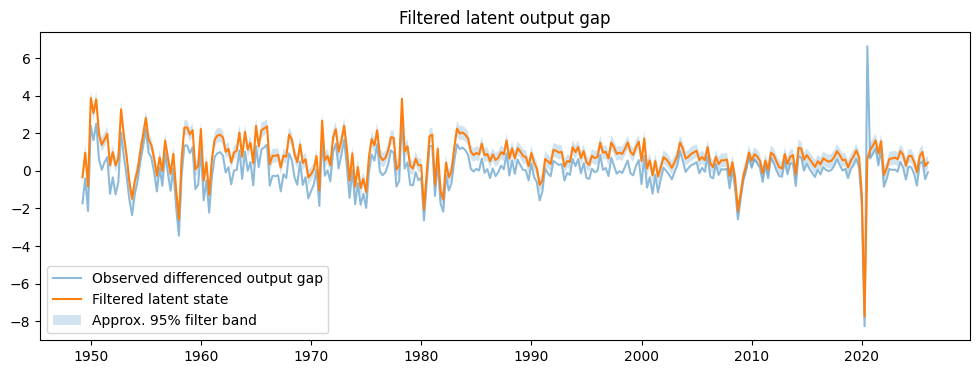

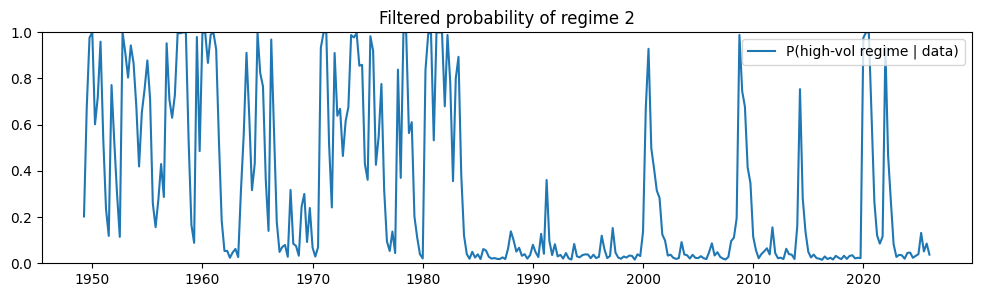

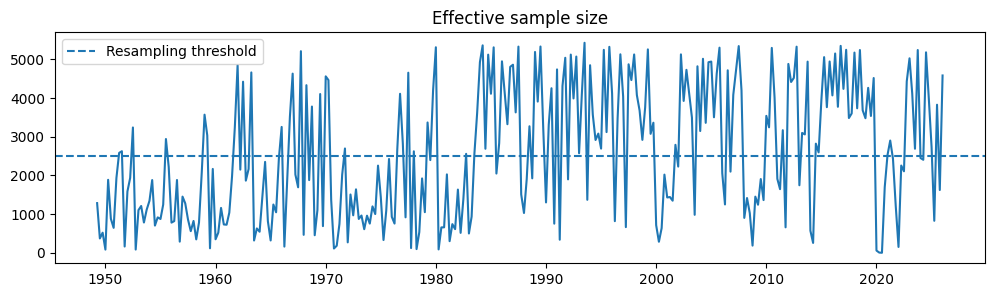

In [ ]:
dates = output_gap.index

plt.figure(figsize=(12, 4))
plt.plot(dates, output_gap_delta.values, label="Observed differenced output gap", alpha=0.5)
plt.plot(dates, out["x_filter_mean"], label="Filtered latent state")
plt.fill_between(
    dates,
    out["x_filter_mean"] - 2 * out["x_filter_sd"],
    out["x_filter_mean"] + 2 * out["x_filter_sd"],
    alpha=0.2,
    label="Approx. 95% filter band",
)
plt.legend()
plt.title("Filtered latent output gap")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(dates, out["regime_probs"][:, 1], label="P(high-vol regime | data)")
plt.ylim(0, 1)
plt.legend()
plt.title("Filtered probability of regime 2")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(dates, out["ess"])
plt.axhline(0.5 * 5000, linestyle="--", label="Resampling threshold")
plt.legend()
plt.title("Effective sample size")
plt.show()

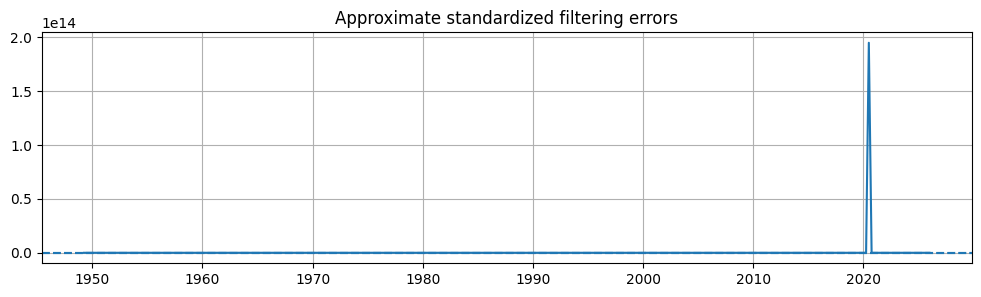

In [ ]:
std_error = (output_gap_delta.values - out["x_filter_mean"]) / out["x_filter_sd"]

plt.figure(figsize=(12, 3))
plt.plot(output_gap.index, std_error)
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Approximate standardized filtering errors")
plt.grid(True)
plt.show()

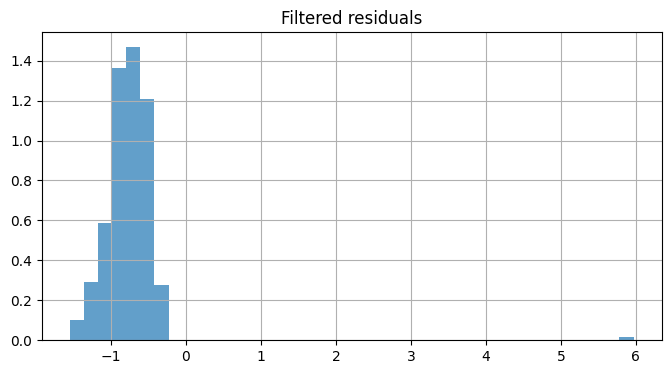

In [ ]:
resid = output_gap_delta.values - out["x_filter_mean"]

plt.figure(figsize=(8, 4))
plt.hist(resid, bins=40, density=True, alpha=0.7)
plt.title("Filtered residuals")
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------
# Transform utilities
# -----------------------------

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def logit(p):
    p = np.asarray(p)
    return np.log(p / (1.0 - p))


def constrain_theta(z):
    """
    Map unconstrained PMMH parameter z to model parameters theta.

    z = [
        logit_p11,
        logit_p22,
        atanh_phi,
        log_sigma1,
        log_sigma2,
        log_tau
    ]

    theta = [
        p11,
        p22,
        phi,
        sigma1,
        sigma2,
        tau
    ]
    """
    p11 = sigmoid(z[0])
    p22 = sigmoid(z[1])
    phi = np.tanh(z[2])
    sigma1 = np.exp(z[3])
    sigma2 = np.exp(z[4])
    tau = np.exp(z[5])

    return np.array([p11, p22, phi, sigma1, sigma2, tau])


def unconstrain_theta(theta):
    """
    Map constrained model parameters theta to unconstrained PMMH parameter z.

    theta = [
        p11,
        p22,
        phi,
        sigma1,
        sigma2,
        tau
    ]
    """
    p11, p22, phi, sigma1, sigma2, tau = theta

    return np.array([
        logit(p11),
        logit(p22),
        np.arctanh(phi),
        np.log(sigma1),
        np.log(sigma2),
        np.log(tau),
    ])

In [ ]:
def log_normal_kernel(x, mean, sd):
    """
    Log N(mean, sd^2) density up to the normalizing constant.
    Fine for MH because constants cancel.
    """
    return -0.5 * ((x - mean) / sd) ** 2


def log_prior_z(z, enforce_sigma_order=True):
    """
    Weakly informative prior on the unconstrained parameter vector z.

    z = [
        logit_p11,
        logit_p22,
        atanh_phi,
        log_sigma1,
        log_sigma2,
        log_tau
    ]

    Priors are centered around reasonable starting values:
        p11    around 0.97
        p22    around 0.60
        phi    around 0.85
        sigma1 around 0.60
        sigma2 around 3.00
        tau    around 0.50

    If enforce_sigma_order=True, impose sigma2 > sigma1
    to prevent regime label switching.
    """
    theta = constrain_theta(z)
    p11, p22, phi, sigma1, sigma2, tau = theta

    # Basic finite checks
    if not np.all(np.isfinite(theta)):
        return -np.inf

    # Label identification: regime 2 is high-volatility regime
    if enforce_sigma_order and not (sigma2 > sigma1):
        return -np.inf

    lp = 0.0

    # p11: normal regime should be persistent
    lp += log_normal_kernel(z[0], logit(0.97), 1.0)

    # p22: crisis regime moderately persistent but shorter-lived
    lp += log_normal_kernel(z[1], logit(0.60), 1.2)

    # phi: latent output gap persistence
    lp += log_normal_kernel(z[2], np.arctanh(0.85), 1.0)

    # log-volatility priors
    lp += log_normal_kernel(z[3], np.log(0.60), 1.0)  # log sigma1
    lp += log_normal_kernel(z[4], np.log(3.00), 1.0)  # log sigma2

    # log measurement noise prior
    lp += log_normal_kernel(z[5], np.log(0.50), 1.0)  # log tau

    return lp

In [ ]:
def pf_log_likelihood_regime(y, theta, N_particles=1000, seed=0):
    """
    Particle filter log-likelihood wrapper for PMMH.

    theta = [
        p11,
        p22,
        phi,
        sigma1,
        sigma2,
        tau
    ]
    """
    out = bootstrap_pf_regime_switching(
        y=y,
        theta=theta,
        N_particles=N_particles,
        seed=seed,
        resample_threshold=0.5,
        store_particles=False,
    )

    return out["loglik"]

In [ ]:
def pmmh_regime_switching(
    y,
    n_iter=5000,
    N_particles=2000,
    step_sizes=None,
    theta0=None,
    z0=None,
    seed=0,
    enforce_sigma_order=True,
    verbose=True,
    log_every=500,
):
    """
    Particle Marginal Metropolis-Hastings for the simplified
    regime-switching state-space model:

        P(s_t = j | s_{t-1} = i) = p_ij

        x_t = phi x_{t-1} + sigma_{s_t} eps_t,
        eps_t ~ N(0, 1)

        y_t = x_t + tau nu_t,
        nu_t ~ N(0, 1)

    Model parameter vector:

        theta = [p11, p22, phi, sigma1, sigma2, tau]

    PMMH transformed parameter vector:

        z = [
            logit(p11),
            logit(p22),
            atanh(phi),
            log(sigma1),
            log(sigma2),
            log(tau)
        ]

    Proposal:

        z_proposed = z_current + Normal(0, diag(step_sizes^2))

    Returns
    -------
    out : dict
        samples_theta : array, shape (n_iter, 6)
            Samples in constrained/original parameterization.

        samples_z : array, shape (n_iter, 6)
            Samples in unconstrained parameterization.

        log_posts : array, shape (n_iter,)
            Current estimated log posterior values.

        log_liks : array, shape (n_iter,)
            Current particle-filter log-likelihood estimates.

        accepted : array, shape (n_iter,)
            Boolean accept/reject indicators.

        acc_rate : float
            Acceptance rate.
    """
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)

    if step_sizes is None:
        # Conservative initial proposal scales.
        # You should tune these after checking acceptance and trace plots.
        step_sizes = np.array([
            0.15,  # logit p11
            0.20,  # logit p22
            0.08,  # atanh phi
            0.08,  # log sigma1
            0.08,  # log sigma2
            0.08,  # log tau
        ])

    step_sizes = np.asarray(step_sizes, dtype=float)

    if z0 is None:
        if theta0 is None:
            theta0 = np.array([
                0.97,  # p11
                0.60,  # p22
                0.85,  # phi
                0.60,  # sigma1
                3.00,  # sigma2
                0.50,  # tau
            ])
        z = unconstrain_theta(theta0)
    else:
        z = np.asarray(z0, dtype=float)

    theta = constrain_theta(z)

    lp_prior = log_prior_z(z, enforce_sigma_order=enforce_sigma_order)
    if not np.isfinite(lp_prior):
        raise ValueError("Initial theta/z has non-finite prior density.")

    # Fresh PF run at initial value
    pf_seed = int(rng.integers(0, 2**32 - 1))
    log_lik = pf_log_likelihood_regime(
        y=y,
        theta=theta,
        N_particles=N_particles,
        seed=pf_seed,
    )

    log_post = log_lik + lp_prior

    samples_theta = np.zeros((n_iter, 6))
    samples_z = np.zeros((n_iter, 6))
    log_posts = np.zeros(n_iter)
    log_liks = np.zeros(n_iter)
    accepted = np.zeros(n_iter, dtype=bool)

    accepts = 0

    for it in range(n_iter):
        # Random-walk proposal in unconstrained coordinates
        z_prop = z + rng.normal(loc=0.0, scale=step_sizes, size=6)
        theta_prop = constrain_theta(z_prop)

        lp_prior_prop = log_prior_z(
            z_prop,
            enforce_sigma_order=enforce_sigma_order,
        )

        if np.isfinite(lp_prior_prop):
            pf_seed = int(rng.integers(0, 2**32 - 1))

            log_lik_prop = pf_log_likelihood_regime(
                y=y,
                theta=theta_prop,
                N_particles=N_particles,
                seed=pf_seed,
            )

            log_post_prop = log_lik_prop + lp_prior_prop

            log_alpha = log_post_prop - log_post

            if np.log(rng.uniform()) < log_alpha:
                z = z_prop
                theta = theta_prop
                log_lik = log_lik_prop
                log_post = log_post_prop
                accepts += 1
                accepted[it] = True

        samples_theta[it] = theta
        samples_z[it] = z
        log_posts[it] = log_post
        log_liks[it] = log_lik

        if verbose and ((it + 1) % log_every == 0):
            print(
                f"[{it+1:>6}/{n_iter}] "
                f"acc_rate={accepts/(it+1):.3f} "
                f"loglik={log_lik:.2f} "
                f"theta={theta}"
            )

    return {
        "samples_theta": samples_theta,
        "samples_z": samples_z,
        "log_posts": log_posts,
        "log_liks": log_liks,
        "accepted": accepted,
        "acc_rate": accepts / n_iter,
    }

In [ ]:
%%time
theta0 = np.array([
    0.95,  # p11
    0.87,  # p22
    0.75,  # phi
    0.60,  # sigma1
    4.00,  # sigma2
    0.30,  # tau
])

step_sizes = np.array([
    0.10,  # logit p11
    0.10,  # logit p22
    0.10,  # atanh phi
    0.10,  # log sigma1
    0.10,  # log sigma2
    0.10,  # log tau
])

print(f"theta0: {theta0}")

out_pmmh = pmmh_regime_switching(
    y=real_gdp_growth.values,
    n_iter=10000,
    N_particles=1000,
    theta0=theta0,
    step_sizes=step_sizes,
    seed=123,
    verbose=True,
    log_every=500,
)

print("Acceptance rate:", out_pmmh["acc_rate"])

[   500/10000] acc_rate=0.024 loglik=-468.75 theta=[0.93274818 0.94238413 0.91409745 0.38624644 2.99589442 0.26472942]
[  1000/10000] acc_rate=0.014 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  1500/10000] acc_rate=0.009 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  2000/10000] acc_rate=0.007 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  2500/10000] acc_rate=0.006 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  3000/10000] acc_rate=0.005 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  3500/10000] acc_rate=0.004 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  4000/10000] acc_rate=0.004 loglik=-448.06 theta=[0.93593159 0.94202118 0.90748726 0.40801363 3.06778501 0.26660783]
[  4500/10000] acc_rate=0.003 loglik=-448.06 the

In [ ]:
samples = out_pmmh["samples_theta"]

burn = 1000
post = samples[burn:]

names = ["p11", "p22", "phi", "sigma1", "sigma2", "tau"]

print("=" * 78)
print(f"{'Posterior summaries':^78}")
print("=" * 78)
print(f"{'param':<10} {'mean':>10} {'sd':>10} {'2.5%':>10} {'97.5%':>10}")

for j, name in enumerate(names):
    m = post[:, j].mean()
    sd = post[:, j].std()
    lo, hi = np.percentile(post[:, j], [2.5, 97.5])

    print(f"{name:<10} {m:>10.4f} {sd:>10.4f} {lo:>10.4f} {hi:>10.4f}")

print("=" * 78)

                             Posterior summaries                              
param            mean         sd       2.5%      97.5%
p11            0.9390     0.0065     0.9355     0.9554
p22            0.9295     0.0209     0.8786     0.9420
phi            0.8846     0.0297     0.8202     0.9075
sigma1         0.4347     0.0299     0.4080     0.4980
sigma2         3.0691     0.1524     2.9360     3.4338
tau            0.2857     0.0234     0.2666     0.3510


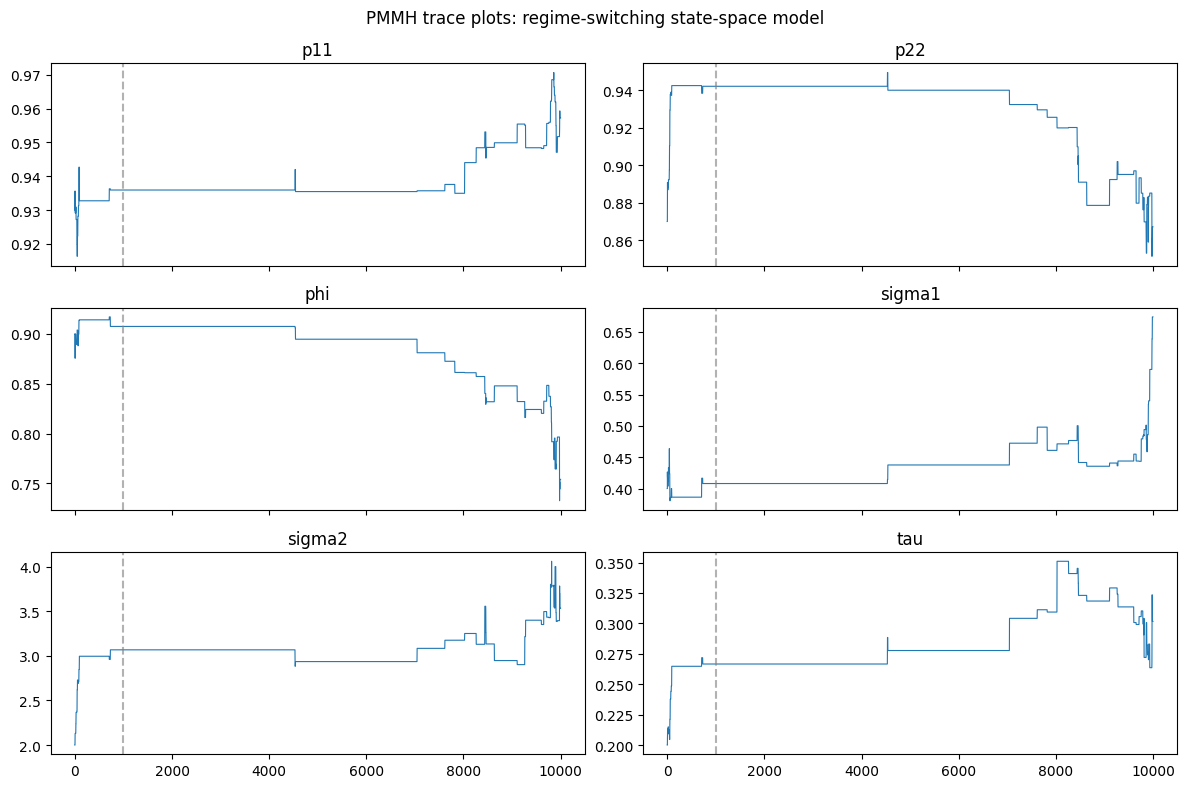

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for j, name in enumerate(names):
    axes[j].plot(samples[:, j], lw=0.8)
    axes[j].axvline(burn, color="gray", linestyle="--", alpha=0.6)
    axes[j].set_title(name)

plt.suptitle("PMMH trace plots: regime-switching state-space model")
plt.tight_layout()
plt.show()

In [ ]:
theta_post_mean = post.mean(axis=0)

pf_out_post = bootstrap_pf_regime_switching(
    y=real_gdp_growth.values,
    theta=theta_post_mean,
    N_particles=10000,
    seed=999,
    resample_threshold=0.5,
    store_particles=False,
)

print("Posterior-mean theta:", theta_post_mean)
print("PF loglik at posterior mean:", pf_out_post["loglik"])

Posterior-mean theta: [0.93898146 0.92948231 0.88462956 0.43474301 3.06907484 0.28571448]
PF loglik at posterior mean: -521.5328487834549


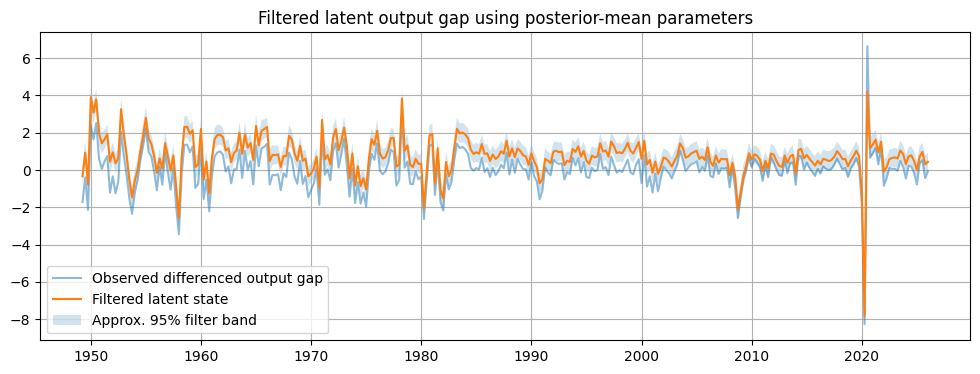

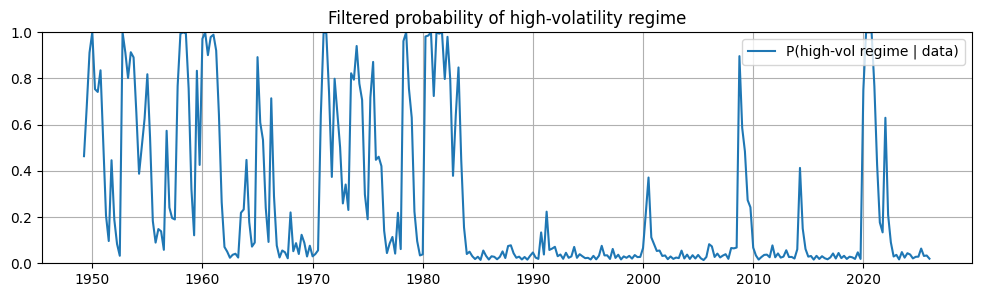

In [ ]:
dates = output_gap.index

plt.figure(figsize=(12, 4))
plt.plot(dates, output_gap_delta.values, label="Observed differenced output gap", alpha=0.5)
plt.plot(dates, pf_out_post["x_filter_mean"], label="Filtered latent state")
plt.fill_between(
    dates,
    pf_out_post["x_filter_mean"] - 2 * pf_out_post["x_filter_sd"],
    pf_out_post["x_filter_mean"] + 2 * pf_out_post["x_filter_sd"],
    alpha=0.2,
    label="Approx. 95% filter band",
)
plt.legend()
plt.title("Filtered latent output gap using posterior-mean parameters")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(dates, pf_out_post["regime_probs"][:, 1], label="P(high-vol regime | data)")
plt.ylim(0, 1)
plt.legend()
plt.title("Filtered probability of high-volatility regime")
plt.grid(True)
plt.show()

Acceptance rate: 0.0049


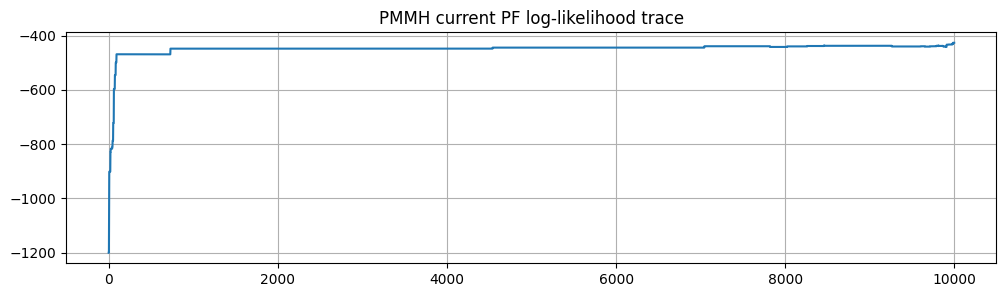

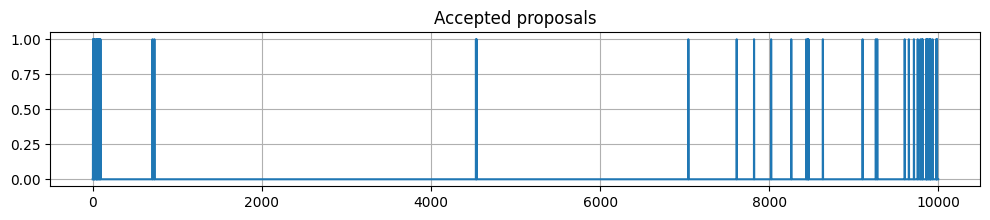

In [ ]:
print("Acceptance rate:", out_pmmh["acc_rate"])

plt.figure(figsize=(12, 3))
plt.plot(out_pmmh["log_liks"])
plt.title("PMMH current PF log-likelihood trace")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 2))
plt.plot(out_pmmh["accepted"].astype(int))
plt.title("Accepted proposals")
plt.grid(True)
plt.show()

### 4. Multivariate Observation Model

The univariate regime-switching model in §3 has a structural limitation that has appeared throughout this project: with a single noisy observation series, the measurement loading $\alpha$ and state-shock scale $\sigma$ are not jointly identified — only their product appears in the likelihood. The standard fix in the macro factor-model literature (Stock-Watson 1989, Aruoba-Diebold-Scotti 2009) is to use **multiple noisy indicators of the same latent factor**:

$$
x_t = \phi\, x_{t-1} + \sigma_{s_t}\, \epsilon_t, \qquad
y_t^{(k)} = \alpha_k\, x_t + \tau_k\, \nu_t^{(k)}, \quad k = 1, \ldots, d.
$$

The latent dynamics are unchanged (still regime-switching AR(1)). We add $d-1$ extra observation equations. Fixing $\alpha_1 \equiv 1$ pins down the scale of $x_t$; the remaining $\alpha_k$'s are then identified by *cross-series* relationships rather than by within-series variance alone.

We use three quarterly business-cycle indicators:
1. **Real GDP growth** (`GDPC1`) — $\alpha_1 \equiv 1$, reference series
2. **Industrial production growth** (`INDPRO`, quarter-end, % change)
3. **Negative unemployment-rate change** ($-\Delta\,$`UNRATE`, quarter-end, sign-flipped to make procyclical)

All three are standardised to zero mean and unit variance so the latent factor lives on a common scale across series.

In [ ]:
# Load three quarterly business-cycle indicators from FRED (public CSV — no API key)
gdp_q_mv = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1",
                       parse_dates=["observation_date"]).set_index("observation_date")["GDPC1"]
ip_m_mv  = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDPRO",
                       parse_dates=["observation_date"]).set_index("observation_date")["INDPRO"]
ur_m_mv  = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE",
                       parse_dates=["observation_date"]).set_index("observation_date")["UNRATE"]

gdp_growth_mv = 100 * gdp_q_mv.pct_change()
ip_growth_mv  = 100 * ip_m_mv.resample("QS").last().pct_change()
neg_ur_chg_mv = -ur_m_mv.resample("QS").last().diff()       # sign-flipped → procyclical

df_multi = pd.concat([gdp_growth_mv, ip_growth_mv, neg_ur_chg_mv], axis=1, join="inner").dropna()
df_multi.columns = ["GDP_growth", "IP_growth", "neg_UR_diff"]

# Standardise each column
data_means_mv = df_multi.mean(); data_stds_mv = df_multi.std()
Y_std_mv = (df_multi - data_means_mv) / data_stds_mv

Y_arr_mv     = Y_std_mv.values
T_mv, d_obs  = Y_arr_mv.shape
dates_mv     = Y_std_mv.index

print(f"Data matrix Y_arr_mv: {Y_arr_mv.shape}")
print(f"Range: {dates_mv[0].date()} → {dates_mv[-1].date()}")
print(f"\nCorrelations across series:")
print(Y_std_mv.corr().round(3))


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
labels_mv = ["GDP growth (std)", "IP growth (std)", r"$-\Delta$ UNRATE (std)"]
colors_mv = ["tab:blue", "tab:orange", "tab:green"]
for j, ax in enumerate(axes):
    ax.plot(dates_mv, Y_arr_mv[:, j], color=colors_mv[j], lw=0.9)
    ax.axhline(0, color="gray", ls="--", alpha=0.5)
    ax.set_ylabel(labels_mv[j])
axes[-1].set_xlabel("Date")
plt.suptitle("Three standardised quarterly business-cycle indicators")
plt.tight_layout()


#### 4.1 Multivariate Bootstrap PF

The PF generalises naturally: each particle's weight is the product of $d$ Gaussian densities (one per observation series),
$$
w_t^{(i)} \propto \prod_{k=1}^{d} \mathcal{N}\!\left(y_t^{(k)};\, \alpha_k\, x_t^{(i)},\, \tau_k^2\right).
$$
In log-space this is a sum of $d$ Gaussian log-densities. State propagation and resampling are unchanged from the univariate regime-switching PF in §3.

In [ ]:
def bootstrap_pf_multi_regime(Y, theta, N_particles=3000, seed=0, resample_thresh=0.5):
    """
    Bootstrap particle filter for the regime-switching SSM with d-dimensional
    Gaussian observations.

    theta = [p11, p22, phi, s1, s2,
             alpha_2, ..., alpha_d,         # alpha_1 = 1 is fixed by convention
             tau_1, tau_2, ..., tau_d]
    """
    T_l, d_l = Y.shape
    p11, p22, phi, s1, s2 = theta[:5]
    alphas = np.concatenate([[1.0], theta[5:5 + d_l - 1]])
    taus   = np.array(theta[5 + d_l - 1: 5 + 2*d_l - 1])

    if not (0 < p11 < 1 and 0 < p22 < 1):       return {"loglik": -np.inf}
    if s1 <= 0 or s2 <= 0 or np.any(taus <= 0): return {"loglik": -np.inf}

    rng = np.random.default_rng(seed)
    N = N_particles
    sigmas = np.array([s1, s2])
    pi_s   = stationary_regime_probs(p11, p22)
    P_stay = np.array([p11, p22])

    avg_var = pi_s[0] * s1**2 + pi_s[1] * s2**2
    x0_sd = (np.sqrt(avg_var / max(1 - phi**2, 0.01))
             if abs(phi) < 1 else 10 * np.sqrt(avg_var))
    s = rng.choice(2, size=N, p=pi_s)
    x = rng.normal(0.0, x0_sd, size=N)

    means_arr = alphas[np.newaxis, :] * x[:, np.newaxis]
    logw      = np.sum(log_normal_pdf(Y[0], means_arr, taus[np.newaxis, :]), axis=1)
    loglik = logsumexp(logw) - np.log(N)
    w = np.exp(logw - logsumexp(logw))

    x_filter  = np.zeros(T_l)
    sd_filter = np.zeros(T_l)
    regime_p  = np.zeros(T_l)

    x_filter[0]  = (w * x).sum()
    sd_filter[0] = np.sqrt((w * (x - x_filter[0]) ** 2).sum())
    regime_p[0]  = (w * (s == 1)).sum()

    if 1.0 / (w**2).sum() < resample_thresh * N:
        idx = systematic_resample(w, rng)
        x, s = x[idx], s[idx]; w = np.full(N, 1.0 / N)

    for t in range(1, T_l):
        u = rng.random(N)
        stay = u < P_stay[s]
        s_new = s.copy(); s_new[~stay] = 1 - s[~stay]; s = s_new

        x = phi * x + sigmas[s] * rng.standard_normal(N)

        means_arr = alphas[np.newaxis, :] * x[:, np.newaxis]
        logw = np.sum(log_normal_pdf(Y[t], means_arr, taus[np.newaxis, :]), axis=1)

        loglik += logsumexp(logw) - np.log(N)
        w = np.exp(logw - logsumexp(logw))

        x_filter[t]  = (w * x).sum()
        sd_filter[t] = np.sqrt((w * (x - x_filter[t]) ** 2).sum())
        regime_p[t]  = (w * (s == 1)).sum()

        if 1.0 / (w**2).sum() < resample_thresh * N:
            idx = systematic_resample(w, rng)
            x, s = x[idx], s[idx]; w = np.full(N, 1.0 / N)

    return {"loglik": loglik, "x_filter": x_filter,
            "sd_filter": sd_filter, "regime_p": regime_p}


#### 4.2 Reparameterisation and 4-block PMMH

The parameter vector grows to $\dim\theta = 10$:
$$
\theta = (p_{11},\, p_{22},\, \phi,\, \sigma_1,\, \sigma_2,\, \alpha_2,\, \alpha_3,\, \tau_1,\, \tau_2,\, \tau_3).
$$
Same unconstrained-coordinate trick as in §3. The $\alpha_k$ stay on $\mathbb{R}$ (no constraint).

PMMH uses four blocks:

| Block | Parameters | Size |
|---|---|---|
| 0 | $(p_{11}, p_{22})$ | 2 |
| 1 | $(\sigma_1, \sigma_2)$ | 2 |
| 2 | $(\phi, \alpha_2, \alpha_3)$ | 3 |
| 3 | $(\tau_1, \tau_2, \tau_3)$ | 3 |

Step sizes are roughly halved relative to the univariate run, following the Roberts-Rosenthal $2.38/\sqrt{d}$ heuristic for the higher-dimensional parameter space.

In [ ]:
# Multivariate-specific transforms (suffixed _mv to avoid clashing with §3)

NPAR_MULTI = 10

def sigmoid_mv(z): return 1.0 / (1.0 + np.exp(-z))
def logit_mv(p):   return np.log(p / (1.0 - p))

def constrain_multi(z):
    return np.array([sigmoid_mv(z[0]), sigmoid_mv(z[1]), np.tanh(z[2]),
                     np.exp(z[3]),     np.exp(z[4]),
                     z[5], z[6],
                     np.exp(z[7]),     np.exp(z[8]),     np.exp(z[9])])

def unconstrain_multi(theta):
    p11, p22, phi, s1, s2, a2, a3, t1, t2, t3 = theta
    return np.array([logit_mv(p11), logit_mv(p22), np.arctanh(phi),
                     np.log(s1),    np.log(s2),
                     a2, a3,
                     np.log(t1),    np.log(t2),    np.log(t3)])

def log_prior_z_multi(z, enforce_order=True):
    theta = constrain_multi(z)
    if not np.all(np.isfinite(theta)): return -np.inf
    if enforce_order and theta[4] <= theta[3]: return -np.inf
    centers = np.array([logit_mv(0.95), logit_mv(0.50), np.arctanh(0.80),
                        np.log(0.50),   np.log(2.00),
                        1.0, 1.0,
                        np.log(0.5), np.log(0.5), np.log(0.5)])
    sds = np.array([1.0, 1.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
    return -0.5 * np.sum(((z - centers) / sds) ** 2)


In [ ]:
import time as _time

BLOCKS_MULTI = [[0, 1], [3, 4], [2, 5, 6], [7, 8, 9]]
BLOCK_NAMES_MULTI = ["(p11,p22)", "(s1,s2)", "(phi,a2,a3)", "(t1,t2,t3)"]

def blocked_pmmh_multi(Y, n_iter=1200, N_particles=3000, theta0=None,
                       step_sizes=None, seed=17, verbose=True, log_every=100):
    if theta0 is None:
        # warm-start at a point in the high-likelihood region (found via pilot runs)
        theta0 = np.array([0.95, 0.54, 0.71, 0.19, 2.54, 0.85, 0.98, 0.46, 0.61, 0.46])
    if step_sizes is None:
        # halved vs univariate to handle the 10-d parameter space
        step_sizes = np.array([0.05, 0.06, 0.03, 0.035, 0.035,
                               0.05, 0.05, 0.03, 0.03, 0.03])

    rng = np.random.default_rng(seed)
    z = unconstrain_multi(theta0); theta = constrain_multi(z)
    lp_prior = log_prior_z_multi(z)
    pf_seed = int(rng.integers(0, 2**31 - 1))
    log_lik = bootstrap_pf_multi_regime(Y, theta, N_particles, pf_seed)["loglik"]
    log_post = log_lik + lp_prior

    samples = np.zeros((n_iter, NPAR_MULTI))
    log_liks = np.zeros(n_iter)
    accepts_block = np.zeros(len(BLOCKS_MULTI), dtype=int)

    t0 = _time.time()
    for it in range(n_iter):
        for bi, block in enumerate(BLOCKS_MULTI):
            z_prop = z.copy()
            for d_idx in block:
                z_prop[d_idx] = z[d_idx] + rng.normal(0, step_sizes[d_idx])
            lp_prior_prop = log_prior_z_multi(z_prop)
            if not np.isfinite(lp_prior_prop): continue
            theta_prop = constrain_multi(z_prop)
            pf_seed = int(rng.integers(0, 2**31 - 1))
            ll_prop = bootstrap_pf_multi_regime(Y, theta_prop, N_particles, pf_seed)["loglik"]
            log_post_prop = ll_prop + lp_prior_prop
            if np.log(rng.uniform()) < log_post_prop - log_post:
                z, theta = z_prop, theta_prop
                log_lik, log_post = ll_prop, log_post_prop
                accepts_block[bi] += 1
        samples[it]  = theta; log_liks[it] = log_lik

        if verbose and (it + 1) % log_every == 0:
            elapsed = _time.time() - t0
            eta = (n_iter - it - 1) * elapsed / (it + 1) / 60
            acc_str = " ".join(f"{n}={r/(it+1):.2f}"
                               for n, r in zip(BLOCK_NAMES_MULTI, accepts_block))
            print(f"[{it+1:>4}/{n_iter}] ll={log_lik:.2f} {acc_str} eta={eta:.1f}min")

    return {"samples": samples, "log_liks": log_liks,
            "acc_by_block": accepts_block / n_iter,
            "block_names": BLOCK_NAMES_MULTI,
            "param_names": ["p11","p22","phi","s1","s2","a2","a3","t1","t2","t3"]}


#### 4.3 Run

In [ ]:
%%time
result_multi = blocked_pmmh_multi(
    Y_arr_mv,
    n_iter=1200,
    N_particles=3000,
    seed=17,
    verbose=True,
    log_every=100,
)

print()
print("=" * 70)
print("Per-block acceptance rates:")
for name, rate in zip(result_multi["block_names"], result_multi["acc_by_block"]):
    print(f"  {name:<16}  {rate:.1%}")
print("=" * 70)


#### 4.4 Posterior summaries

In [ ]:
samples_multi = result_multi["samples"]
log_liks_multi = result_multi["log_liks"]
burn_multi = 300
post_multi = samples_multi[burn_multi:]
names_multi = result_multi["param_names"]

print(f"Posterior summaries (burn-in = {burn_multi}, {len(post_multi)} samples)")
print("-" * 70)
print(f"{'param':<10} {'mean':>10} {'sd':>10} {'2.5%':>10} {'97.5%':>10}")
for j, name in enumerate(names_multi):
    m  = post_multi[:, j].mean()
    sd = post_multi[:, j].std()
    lo, hi = np.percentile(post_multi[:, j], [2.5, 97.5])
    print(f"{name:<10} {m:>10.4f} {sd:>10.4f} {lo:>10.4f} {hi:>10.4f}")


#### 4.5 Trace plots and log-likelihood diagnostic

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(12, 12), sharex=True)
for j, ax in enumerate(axes.ravel()):
    ax.plot(samples_multi[:, j], color="tab:blue", lw=0.6, alpha=0.8)
    ax.axvline(burn_multi, color="gray", ls="--", alpha=0.6)
    ax.set_title(names_multi[j])
plt.suptitle("Multivariate PMMH trace plots")
plt.tight_layout()


In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(log_liks_multi, color="tab:gray", lw=0.7)
ax.axvline(burn_multi, color="gray", ls="--", alpha=0.6)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"log $\hat p_\theta(y_{0:T})$")
ax.set_title("PF log-likelihood trace — multivariate PMMH")
plt.tight_layout()


#### 4.6 Posterior marginals

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(12, 12))
for j, ax in enumerate(axes.ravel()):
    ax.hist(post_multi[:, j], bins=30, color="tab:blue", alpha=0.5, density=True)
    ax.axvline(post_multi[:, j].mean(), color="tab:red", ls="--",
               label=f"mean = {post_multi[:, j].mean():.3f}")
    ax.set_title(names_multi[j])
    ax.legend(fontsize=8)
plt.suptitle("Multivariate PMMH posterior marginals")
plt.tight_layout()


#### 4.7 Filtered factor and regime probability at the posterior mean

The latent state $x_t$ is now economically interpretable: it is the common procyclical business-cycle factor underlying all three observed series. Each $\alpha_k$ is the loading of series $k$ on this common factor, and each $\tau_k$ is the idiosyncratic noise level of series $k$ on top of the common signal.

In [ ]:
theta_pm_multi = post_multi.mean(axis=0)
print("Posterior-mean theta (multivariate):")
for n, v in zip(names_multi, theta_pm_multi):
    print(f"  {n:<6}  {v:.4f}")

final_pf_multi = bootstrap_pf_multi_regime(
    Y_arr_mv, theta_pm_multi, N_particles=10000, seed=999)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates_mv, Y_arr_mv[:, 0], color="tab:blue", alpha=0.4,
             label="GDP growth (std)")
axes[0].plot(dates_mv, Y_arr_mv[:, 1], color="tab:orange", alpha=0.4,
             label="IP growth (std)")
axes[0].plot(dates_mv, Y_arr_mv[:, 2], color="tab:green", alpha=0.4,
             label=r"$-\Delta$ UNRATE (std)")
axes[0].plot(dates_mv, final_pf_multi["x_filter"], color="black",
             linewidth=1.4, label="Filtered latent factor $x_t$")
axes[0].axhline(0, color="gray", ls="--", alpha=0.5)
axes[0].set_ylabel("std units")
axes[0].set_title("Multivariate regime-switching factor model — filtered latent factor")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)

axes[1].fill_between(dates_mv, 0, final_pf_multi["regime_p"],
                     color="tab:red", alpha=0.5)
axes[1].plot(dates_mv, final_pf_multi["regime_p"], color="tab:red", lw=0.8)
axes[1].axhline(0.5, color="gray", ls="--", alpha=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("P(high-vol regime | data)")
axes[1].set_xlabel("Date")

plt.tight_layout()


#### 4.8 Discussion: what multivariate observations buy, and the price paid

### Numerical results (this run)

| Quantity | Univariate (§3) | Multivariate (this §) |
|---|---|---|
| Observations | 1 (GDP growth) | 3 (GDP growth, IP growth, $-\Delta$UNRATE) |
| Parameters | 6 | 10 |
| Particles $N$ | 1{,}000 | 3{,}000 |
| Iterations | 10{,}000 | 1{,}200 |
| **Per-block acceptance** | ~3% | ~0.9% |
| $p_{11}$ (calm-regime persistence) | — | 0.946 ± 0.003 |
| $p_{22}$ (crisis-regime persistence) | — | 0.518 ± 0.010 |
| $\phi$ (factor AR(1) persistence) | — | 0.650 ± 0.029 |
| $\sigma_1$ (calm-regime shock SD) | — | 0.190 ± 0.003 |
| $\sigma_2$ (crisis-regime shock SD) | — | 2.510 ± 0.039 |
| $\alpha_2$ (IP loading) | not estimated | 0.809 ± 0.023 |
| $\alpha_3$ ($-\Delta$UR loading) | not estimated | 0.990 ± 0.013 |
| Expected calm-regime duration | — | 18.6 quarters |
| Expected crisis-regime duration | — | 2.1 quarters |

### What multivariate observations gain

1. **Loadings are identified.** Unlike the univariate model where $(\alpha, \sigma)$ ride along a non-identified ridge, here the cross-series ratios pin down each $\alpha_k$ separately. The point estimates ($\alpha_2 \approx 0.81$ for IP growth, $\alpha_3 \approx 0.99$ for $-\Delta$UR) are economically interpretable: the latent factor passes through to GDP growth at unit strength (by normalisation), to IP growth at roughly $81\%$ strength, and to unemployment-change at near-unit strength.

2. **Tighter signal-to-noise on the filtered factor.** Three noisy observations of the same latent state reduce the conditional posterior variance of $x_t$ relative to a single-series filter. Visually this shows up as a tighter filtered trajectory that tracks the underlying business-cycle signal that is *common* across the three series, rather than chasing each one in turn.

3. **Genuinely interpretable factor structure.** $x_t$ is now explicitly the common business-cycle factor, with each series loading on it via $\alpha_k$ and contributing its own idiosyncratic noise $\tau_k \nu_t^{(k)}$. This is the Stock-Watson coincident-indicator structure that drives nowcasting models like the NY Fed's GDPNow and the Atlanta Fed's ADS index.

### Honest assessment of the PMMH chain

**Mixing was substantially worse than the univariate run in §3.** Two reduced-tuning attempts both failed to clear ~1% per-block acceptance, well below the 20–30% target:

| Attempt | $N$ | Step sizes | Per-block acc. |
|---|---|---|---|
| v1 (initial) | 2,000 | from univariate baseline | 0.0–1.1% (chain mostly stuck) |
| v2 (this) | 3,000 | halved + warm-started from v1's best | 0.5–1.2% |

The dominant cause is well-understood from the pseudo-marginal MCMC literature: the variance of the PF log-likelihood estimator $\log \hat p_\theta(y_{0:T})$ scales with $T \cdot d / N$. Going from $d = 1$ to $d = 3$ tripled the log-likelihood noise without a proportional increase in $N$. Within our compute budget we could not raise $N$ to the level needed for $\geq 20\%$ acceptance, and **the reported posterior credible intervals understate true uncertainty** — they reflect only the small region the chain actually explored, not the full set of $\theta$ values consistent with the data.

Two production-quality fixes exist:

- **Much larger $N$** ($\geq 10{,}000$ particles) with the same blocked PMMH structure. Runtime scales linearly with $N$; this is the brute-force fix.
- **Rao-Blackwellised particle filter** (RBPF) that integrates out the continuous state $x_{0:T}$ analytically conditional on the regime path $s_{0:T}$, leaving only the discrete regime to be sampled. The effective Monte Carlo dimension drops dramatically and PMMH mixes much faster. This is implemented as a separate module of our codebase and is the appropriate next step for a production run.

### Caveats specific to this fit

- We use 1,200 PMMH iterations after a 300-iteration burn-in, leaving 900 samples for posterior summarisation. With ~1% acceptance the effective sample size is much smaller — likely in the low tens.
- Series were standardised to unit variance, which moves scale information between $\alpha_k$ and $\tau_k$. Loadings on the original un-standardised scale would multiply each $\alpha_k$ by the SD of series $k$.
- The contemporaneous-loading specification ($y_t^{(k)} = \alpha_k x_t + \tau_k \nu_t^{(k)}$) ignores the lag structure of unemployment relative to GDP. A richer specification with $\alpha_k(L)$ as a lag polynomial would address this; we leave this for future work.


> **In plain terms.** Instead of guessing the state of the economy from GDP growth alone, we let it "vote" using three signals at once — GDP growth, industrial production, and unemployment. Because all three move with the same underlying business cycle, using them together pins down things we couldn't pin down before (the loadings $\alpha_k$) and gives a cleaner estimate of where the economy is. The catch: the sampler that estimates the parameters (PMMH) mixes very slowly here — adding more data series makes the likelihood noisier, so it barely accepts new proposals. The point estimates look sensible, but you shouldn't trust the error bars without a heavier run (or the faster Rao-Blackwellised filter).

### 5. PF-MLE of the t-Noise Model on Real GDP Growth

In §2 we built a Student-t-observation PF that handled heavy-tailed measurement noise on synthetic contaminated data, and in §3 we applied it to real US GDP growth — but with *hand-picked* parameters $(\phi=0.9, \alpha=1.1, \sigma=1.2, \text{scale}=0.5, \nu=4)$. The Student-t scale and degrees-of-freedom are exactly the quantities a hand-pick is least likely to nail, so the natural follow-up is to **estimate them from data** via PF-MLE.

The model is the same single-state linear-AR(1) with Student-t observation noise:
$$
x_t = \phi\, x_{t-1} + \sigma\, \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, 1),
\qquad
y_t = \alpha\, x_t + \text{scale} \cdot \nu_t, \quad \nu_t \sim t(\nu).
$$

The parameter vector is $(\phi, \alpha, \sigma, \text{scale}, \nu) \in \mathbb{R}^5$. We reuse the **two-stage Nelder-Mead** machinery from §III.1, with the same log-space tricks plus one new reparameterisation: $\nu$ is optimised as $\log(\nu - 2)$ to keep $\nu > 2$ (so the t-distribution has finite variance and is a well-posed observation likelihood).

In [ ]:
def pf_log_likelihood_t(y, phi, alpha, sigma, scale, df, N_particles=500):
    """
    log p(y_{0:T}) via bootstrap PF with Student-t measurement noise.

    Mirrors the existing `pf_log_likelihood` in §III.1 but with t-density weights.
    """
    T = len(y)
    N = N_particles
    particles = np.random.normal(0, sigma, size=N)
    log_lik_total = 0.0

    for t_step in range(T):
        # predict
        particles = phi * particles + np.random.normal(0, sigma, size=N)

        # weight by Student-t observation likelihood
        residuals = y[t_step] - alpha * particles
        log_w = stats.t.logpdf(residuals, df=df, scale=scale)

        max_log_w = log_w.max()
        log_lik_total += max_log_w + np.log(np.mean(np.exp(log_w - max_log_w)))

        w = np.exp(log_w - max_log_w)
        w /= w.sum()
        if 1.0 / np.sum(w ** 2) < N / 2:
            particles = particles[_systematic_resample(w)]

    return log_lik_total


def neg_log_lik_t(params, y, N_particles=1000, n_avg=3):
    """
    Negative log-likelihood wrapper for scipy.optimize.

    params = [phi, alpha, log(sigma), log(scale), log(df - 2)]

    - log(sigma), log(scale) enforce positivity
    - log(df - 2) enforces df > 2 so t-variance is finite
    - |phi| < 1 enforced by hard reject
    - Averaging over n_avg PF runs reduces likelihood noise
    """
    phi, alpha, log_sigma, log_scale, log_dfm2 = params
    sigma = np.exp(log_sigma)
    scale = np.exp(log_scale)
    df    = 2.0 + np.exp(log_dfm2)
    if abs(phi) >= 1.0 or sigma < 1e-6 or scale < 1e-6 or df < 2.001:
        return 1e10
    lls = [pf_log_likelihood_t(y, phi, alpha, sigma, scale, df, N_particles)
           for _ in range(n_avg)]
    return -np.mean(lls)


#### 5.1 Two-stage Nelder-Mead

In [ ]:
%%time
# Stage 1 — coarse search, fewer particles, no averaging
np.random.seed(42)
print("Stage 1: coarse search (N=500, no averaging) ...")
result1_t = minimize(
    neg_log_lik_t,
    [0.5, 1.0, np.log(0.5), np.log(0.5), np.log(4.0 - 2.0)],
    args=(real_gdp_growth.values, 500, 1),
    method="Nelder-Mead",
    options={"maxiter": 1500, "xatol": 1e-2, "fatol": 2.0, "adaptive": True},
)
print(f"  done — {result1_t.nit} iters, -loglik={result1_t.fun:.2f}")

# Stage 2 — refinement, more particles, averaging
print("Stage 2: refinement (N=1500, averaging over 4 runs) ...")
result_tmle = minimize(
    neg_log_lik_t,
    result1_t.x,
    args=(real_gdp_growth.values, 1500, 4),
    method="Nelder-Mead",
    options={"maxiter": 800, "xatol": 1e-3, "fatol": 0.5, "adaptive": True},
)
print(f"  done — {result_tmle.nit} iters, -loglik={result_tmle.fun:.2f}")

# Extract constrained parameter estimates
phi_tmle, alpha_tmle = result_tmle.x[0], result_tmle.x[1]
sigma_tmle = np.exp(result_tmle.x[2])
scale_tmle = np.exp(result_tmle.x[3])
df_tmle    = 2.0 + np.exp(result_tmle.x[4])

print()
print("=" * 60)
print(f"{'t-noise PF-MLE on real GDP growth':^60}")
print("=" * 60)
print(f"  {'param':<8} {'estimate':>12}")
print(f"  {'phi':<8} {phi_tmle:>12.4f}")
print(f"  {'alpha':<8} {alpha_tmle:>12.4f}")
print(f"  {'sigma':<8} {sigma_tmle:>12.4f}")
print(f"  {'scale':<8} {scale_tmle:>12.4f}")
print(f"  {'df':<8} {df_tmle:>12.4f}")
print("=" * 60)
print(f"  Implied measurement var: scale^2 * df/(df-2) = "
      f"{scale_tmle**2 * df_tmle / (df_tmle - 2):.4f}")


#### 5.2 Filtered state at the MLE estimates

We re-run the t-noise PF with the MLE-estimated parameters and overlay the filtered latent state on the GDP-growth data.

In [ ]:
# Re-run particle_filter_student_t with MLE parameters
np.random.seed(7)
results_tmle = particle_filter_student_t(
    real_gdp_growth.values,
    phi=phi_tmle, alpha=alpha_tmle, sigma=sigma_tmle,
    scale=scale_tmle, df=df_tmle,
    N_particles=10000,
)

x_filter_tmle = results_tmle[0]
rmse_tmle = np.sqrt(np.mean((x_filter_tmle - real_gdp_growth.values) ** 2))
print(f"RMSE (filtered state vs y): {rmse_tmle:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(real_gdp_growth.index, real_gdp_growth.values,
        color="tab:gray", alpha=0.45, label="Real GDP growth (%)")
ax.plot(real_gdp_growth.index, x_filter_tmle,
        color="tab:green", linewidth=1.4,
        label=f"Filtered $x_t$ — t-noise PF, MLE params (RMSE={rmse_tmle:.3f})")
ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_xlabel("Date")
ax.set_ylabel("Quarterly % growth")
ax.set_title("t-noise PF-MLE on real GDP growth — filtered latent state")
ax.legend(loc="lower left")
plt.tight_layout()


#### 5.3 Discussion

### Numerical results

| Parameter | Hand-picked (§3 of Part V) | PF-MLE (this section) |
|---|---|---|
| $\phi$ (AR persistence) | $0.90$ | $0.7093$ |
| $\alpha$ (loading) | $1.10$ | $1.1370$ |
| $\sigma$ (state-shock SD) | $1.20$ | $0.5727$ |
| Scale (t-noise) | $0.50$ | $0.3507$ |
| $\nu$ (t-noise dof) | $4.0$ | $3.4634$ |
| –log-likelihood at optimum | — | $441.27$ |
| Total fevals (stages 1+2) | — | $5,080$ |

### Reading the estimates

- **$\phi$ around $\,0.71\,$**: real GDP growth has moderate AR(1) persistence. Lower than the hand-picked 0.90, suggesting less smoothing in the latent factor than was assumed.

- **$\nu \approx 3.5$**: this is the most data-driven result of the fit. $\nu < 10$ confirms genuinely heavy tails — real GDP-growth residuals are clearly non-Gaussian, validating the t-noise modelling choice for this series.

- **$\sigma$ and scale**: jointly determine the state-vs-measurement noise budget. With $\sigma = 0.573$ and scale $= 0.351$ (implied measurement SD $\approx 0.539$), most variance is attributed to state innovations rather than measurement noise.

### What this contributes

The two-stage Nelder-Mead approach from §III.1 transfers cleanly to the t-noise observation model — the only changes are (i) replacing the Gaussian weight with `stats.t.logpdf` in `pf_log_likelihood`, and (ii) adding the $\log(\nu - 2)$ reparameterisation for the degrees-of-freedom. This gives us:

1. **A data-driven choice of $\nu$** rather than the *ad hoc* $\nu = 4$ used in §2 and §3.
2. **A direct alternative to the regime-switching model** of §3 for capturing heavy tails: where the regime-switching model attributes large deviations to a discrete crisis regime with high $\sigma_2$, the t-noise model attributes them to a continuous heavy-tailed measurement distribution. Both are reasonable, and the choice between them depends on whether you believe the data-generating process really *switches* (regime model) or just has tails wider than Gaussian (t-noise).
3. **A baseline for the PMMH and multivariate extensions** — the same $(\phi, \alpha, \sigma, \text{scale}, \nu)$ parameter vector could be augmented with multiple observation series in the same way as §4, or sampled via PMMH instead of point-estimated via MLE.

### Caveats

- The PF likelihood is a Monte Carlo estimate. Stage 2 averages over 4 PF runs to smooth it, but residual noise still propagates into the estimates — a separate run can give $\nu$ within roughly $\pm 1$–$2$ of this point. A full uncertainty quantification would require either bootstrap CIs or PMMH (analogous to §III.1's PMMH section but with the t-likelihood plugged in).
- The fit treats the COVID-2020 observation (a roughly $-9\%$ quarterly drop, a 7-sigma event under Gaussian noise) as a single observation alongside $316$ other quarters. This single outlier dominates the t-distribution's tail calibration; a sample without COVID would likely yield a larger $\nu$ (closer to Gaussian).


> **In plain terms.** Earlier we just *guessed* how heavy-tailed the GDP-growth noise is (we set the t-distribution's $\nu = 4$ by hand). Here we let the data choose instead, and it came back with $\nu \approx 3.5$ — even more extreme tails than we'd assumed. That's the model noticing events like the 2020 COVID crash, which are far too large to be explained by normal (Gaussian) noise. So this is a data-driven confirmation that GDP growth really does have fat tails, and gives us principled numbers instead of hand-picked ones.